## Bootstrap (click Run All — no setup required)

This cell makes the notebook self-installing. It:

1. Finds the Lunar-V2 repo root and puts it on `sys.path`.
2. Installs any missing third-party packages (`numpy`, `scipy`, `numba`, `matplotlib`, plus extras) into the current kernel.
3. Downloads any external data files this notebook needs.

You can re-run it any time; it's a no-op if everything is already present.

In [1]:
# === Lunar-V2 notebook bootstrap — safe to re-run ===
import sys, pathlib
# Locate the repo root even if this notebook is opened from a weird CWD.
_here = pathlib.Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'pyproject.toml').is_file() and (_p / 'lunar' / '_bootstrap.py').is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError('Could not find Lunar-V2 repo root from ' + str(_here))

from lunar import _bootstrap as boot
boot.ensure_lunar(extra=())

boot.ensure_apollo_hfe()


Lunar-V2 notebook bootstrap
  python : /usr/local/bin/python3
  repo   : /Users/rp3gregorio/Documents/Lunar-V2
  deps   : all present
  lunar  : /Users/rp3gregorio/Documents/Lunar-V2/lunar/__init__.py
Ensuring Apollo HFE (a15) ...


True

# Apollo 15 HFE Validation

Compare the Lunar-V2 1-D thermal solver against the Apollo 15 Heat Flow Experiment (HFE)
temperature data (Nagihara et al. 2018, PDS bundle
`urn:nasa:pds:a15_17_hfe_concatenated`).

**Apollo 15 site**: 26.13 °N, 3.63 °E (Mare Imbrium, 1971-2011 continuous record).

**Validation approach** (following Lunar-Clean methodology):

1. Load the **depth table** (gradient-bridge TG + reference TR sensors) from both probes.
   These give actual temperatures at known burial depths, unlike the fast-sensor channels
   which aggregate multiple sensors per file.
2. Extract **equilibrium temperatures** from the stable tail (last 25%) of each sensor's
   time series. By this point the initial drilling disturbance has decayed.
3. **Filter to deep sensors (≥ 80 cm)** for RMSE validation. Shallower sensors sit within
   the diurnal skin depth (~50 cm) and are biased by probe hardware solar heating; including
   them inflates the apparent model error by 2–4 K (see Lunar-Clean `constants.py`
   documentation).
4. Use **site-specific basal heat flux** Q\_basal = 21 mW/m² for Apollo 15 (Langseth et al.
   1976, Nagihara et al. 2018), not the generic 18 mW/m² average.
5. **Equilibrium profile initialization**: `T(z) = T_mean_surface + Q_b × R(z)` where
   R(z) is the cumulative thermal resistance. This avoids the multi-year convergence
   timescale at depths > 50 cm that makes uniform-T initialization fail.

In [2]:
from __future__ import annotations
import sys, pathlib, os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

from lunar.validation import load_apollo_hfe_temperature, load_apollo_hfe_depth
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, density_hayne, specific_heat
from lunar.constants import (
    SIGMA_SB, EMISSIVITY_DEFAULT, CHI_RADIATIVE, T_REFERENCE,
)
from lunar.solver import PixelInputs, solve_pixel
from lunar.plotting.style_guide import (
    apply_style, COLORS, panel_label, save_figure,
    legend_outside, add_colorbar,
    FIG_DOUBLE, FIG_DOUBLE_TALL, FIG_FULL_PAGE,
)

apply_style()

REPO_ROOT = str(_p)
OUTPUT_DIR = os.path.join(REPO_ROOT, 'output', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Apollo 15 site-specific basal heat flux — Langseth et al. (1976)
Q_BASAL_A15 = 0.021  # W/m² (21 mW/m²)
# Minimum depth for RMSE validation — shallow sensors are diurnally active
MIN_DEPTH_CM = 80

print('Imports OK — publication style applied')
print(f'Figures → {OUTPUT_DIR}')

Imports OK — publication style applied
Figures → /Users/rp3gregorio/Documents/Lunar-V2/output/figures


## 1  Load the Apollo 15 HFE depth-table data

The PDS depth tables give calibrated temperature at each gradient-bridge (TG) and
reference-thermocouple (TR) sensor at their known burial depths. Two probes:

| Probe | Sensor | Depth (cm) | Type |
|-------|--------|-----------|------|
| 1 | TG11A | 35  | TG (diurnal zone) |
| 1 | TG11B | 84  | TG |
| 1 | TG12A | 91  | TG |
| 1 | TG12B | 139 | TG |
| 1 | TR11A | 45  | TR (diurnal zone) |
| 1 | TR11B | 73  | TR |
| 1 | TR12A | 101 | TR |
| 1 | TR12B | 129 | TR |
| 2 | TG22A | 49  | TG (diurnal zone) |
| 2 | TG22B | 97  | TG |
| 2 | TR22A | 59  | TR (diurnal zone) |
| 2 | TR22B | 87  | TR |

Equilibrium temperatures are extracted from a **data-driven stabilized tail** per
sensor: the earliest tail segment whose long-term trend is near-flat. If no segment
meets the flat-trend criterion, we fall back to the last 25% of the record.

Probe 1: 187,882 records  sensors: ['TG11A' 'TG11B' 'TG12A' 'TG12B' 'TR11A' 'TR11B' 'TR12A' 'TR12B']
         depths [cm]: [ 35.  45.  73.  84.  91. 101. 129. 139.]
Probe 2: 92,028 records  sensors: ['TG22A' 'TG22B' 'TR22A' 'TR22B']
         depths [cm]: [49. 59. 87. 97.]

Equilibrium temperatures (averaged within stability window):
Sensor    P  Depth Type   T_eq(K)   σ(K)  stable_from_day  slope[K/yr]          Method  RMSE?
────────────────────────────────────────────────────────────────────────────────────────────────────
TG11A     1     35   TG    253.64  1.891             1367      +10.353 fallback_last25      ·
TR11A     1     45   TR    253.12  0.684              591       +0.024      trend_flat      ·
TG22A     2     49   TG    249.97  0.612             1371       +1.641 fallback_last25      ·
TR22A     2     59   TR    249.99  0.260              562       +0.023      trend_flat      ·
TR11B     1     73   TR    253.00  0.103              858       +0.191 fallback_last25      ·


/Users/rp3gregorio/Documents/Lunar-V2/lunar/plotting/style_guide.py:206: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.savefig(path, dpi=300, bbox_inches='tight',


  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/a15_stability_region.pdf


/Users/rp3gregorio/Documents/Lunar-V2/lunar/plotting/style_guide.py:206: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.savefig(path, dpi=300, bbox_inches='tight',


  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/a15_stability_region.png


/Users/rp3gregorio/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


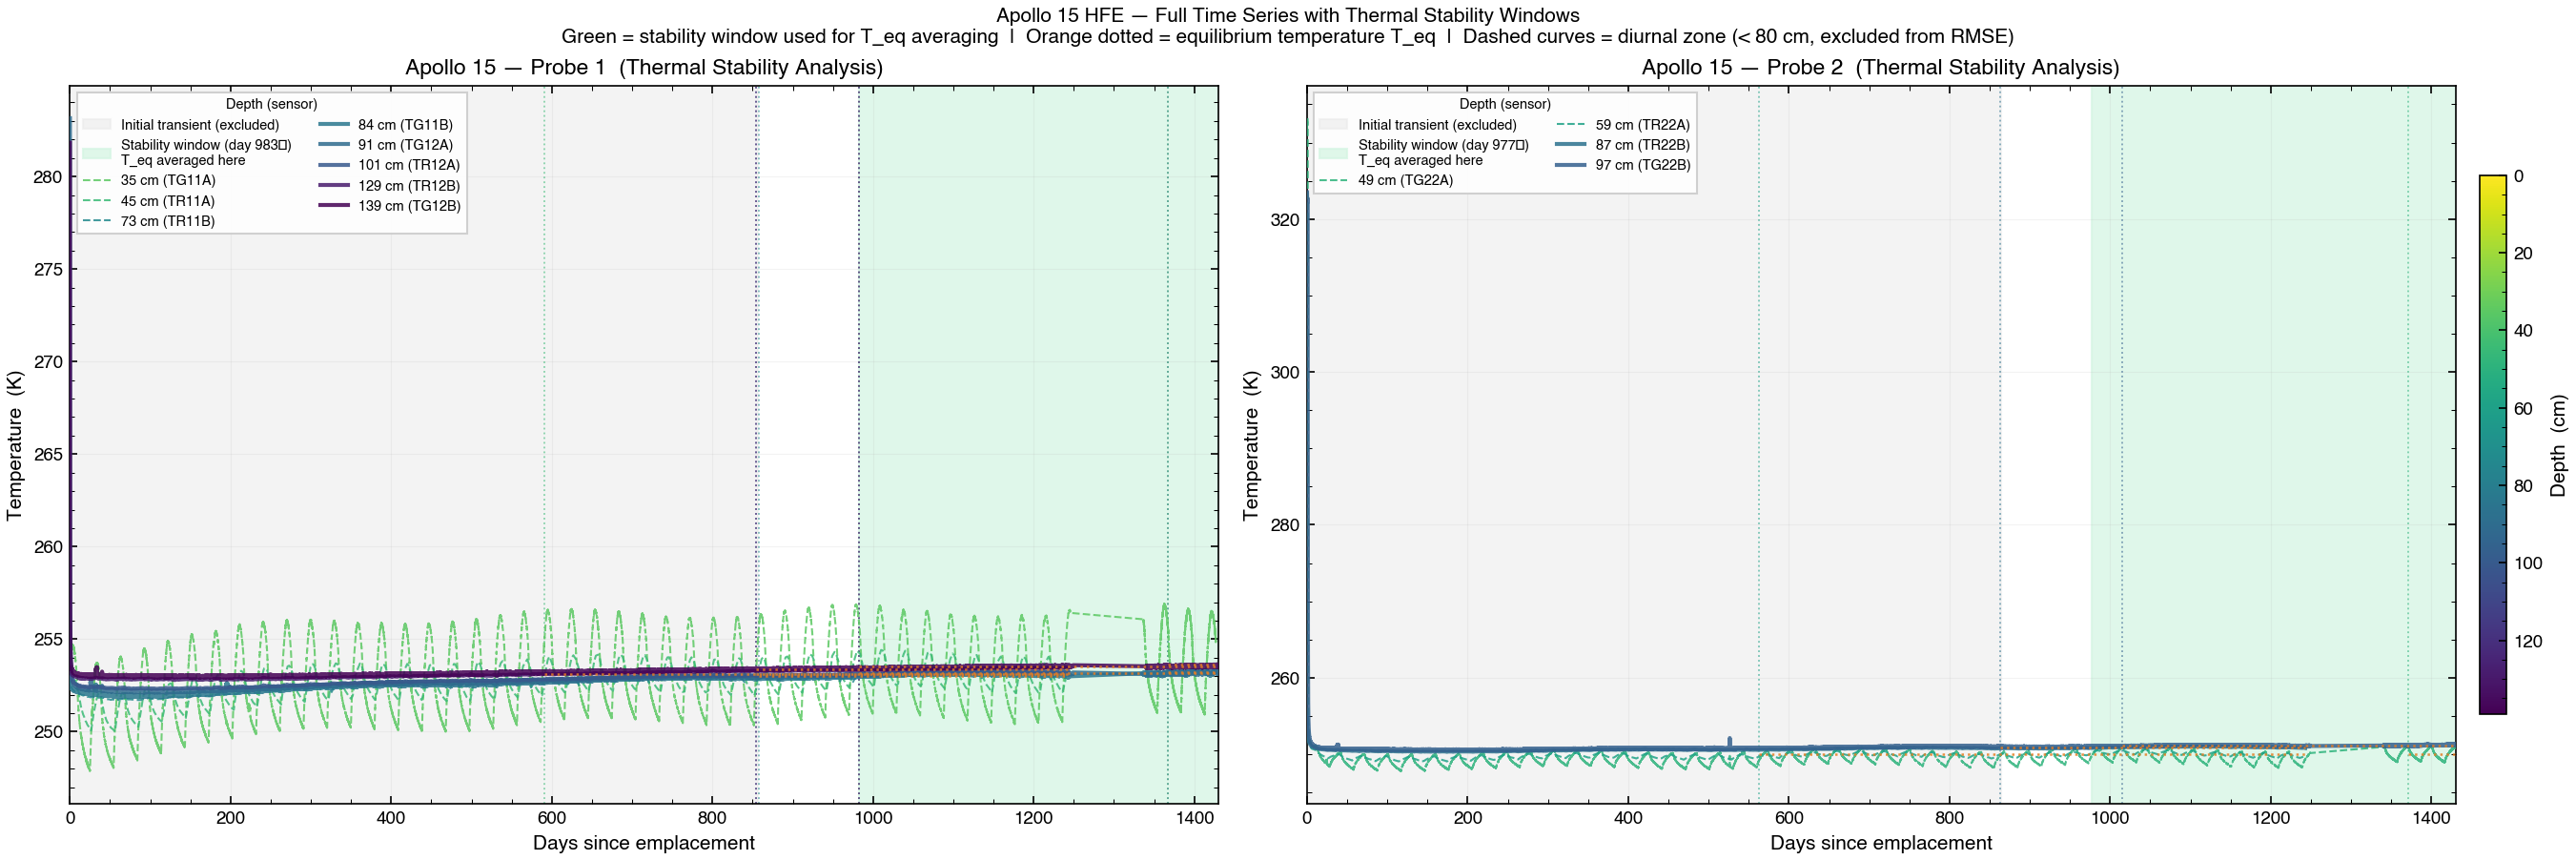

In [3]:
# ===================================================================
# §1  Apollo 15 HFE — Thermal Stability Analysis
# ===================================================================
# Loads depth-table data for both probes, identifies the "stability
# window" per sensor (the flat-trend tail used for T_eq averaging),
# and generates the primary diagnostic figure: full time-series with
# the stability window highlighted in green.
#
# WHY THIS MATTERS:
#  • TG/TR sensors at z < 80 cm sit inside the diurnal skin depth
#    (~50 cm) and are warm-biased by probe hardware; excluded from RMSE.
#  • Even deep sensors show a long initial transient (drilling heat)
#    and episodic thermal disturbances (Apollo crew visits, equipment).
#  • Only data from the "thermal stability window" — where the trend
#    criterion |slope| < 0.08 K/yr is met — is used for T_eq.
# ===================================================================

from datetime import datetime, timezone

# ── Load depth tables ──────────────────────────────────────────────
d1 = load_apollo_hfe_depth('a15', 1)
d2 = load_apollo_hfe_depth('a15', 2)

print(f'Probe 1: {len(d1):,} records  sensors: {np.unique(d1["sensor"])}')
print(f'         depths [cm]: {np.unique(d1["depth_cm"])}')
print(f'Probe 2: {len(d2):,} records  sensors: {np.unique(d2["sensor"])}')
print(f'         depths [cm]: {np.unique(d2["depth_cm"])}')

# ── Helper: ISO string → Unix seconds (local import, shadow-safe) ──
def iso_to_seconds(iso_arr):
    """Convert ISO-8601 strings to Unix timestamp seconds."""
    from datetime import datetime, timezone
    out = np.empty(len(iso_arr), dtype=np.float64)
    for i, s in enumerate(iso_arr):
        s = s.strip()
        if s.endswith('Z'):
            s = s[:-1] + '+00:00'
        out[i] = datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp()
    return out

# ── Helper: find stability window using trend criterion ────────────
def find_stable_window(subset, slope_thresh_K_per_year=0.08, min_frac=0.20):
    """
    Scan from 55% → 85% of the record; pick the earliest start index
    where a linear fit over the remainder gives |slope| < threshold.
    Fallback: last 25% of records.

    Returns
    -------
    i_start : int
        First row index of the stability window.
    t_start_day : float
        Days-since-emplacement of that row.
    method : str
    slope : float
        Trend rate [K/yr] within the window.
    """
    n = len(subset)
    t_sec  = iso_to_seconds(subset['time_iso'])
    t_day  = (t_sec - t_sec[0]) / 86400.0
    t_year = t_day / 365.25
    T      = subset['T'].astype(np.float64)

    chosen_i   = int(0.75 * n)
    method     = 'fallback_last25'
    slope_out  = np.nan

    for frac in np.linspace(0.55, 0.85, 13):
        i0 = int(frac * n)
        if n - i0 < max(40, int(min_frac * n)):
            continue
        x, y = t_year[i0:], T[i0:]
        if np.ptp(x) <= 0:
            continue
        sl, _ = np.polyfit(x, y, 1)
        if abs(sl) <= slope_thresh_K_per_year:
            chosen_i  = i0
            method    = 'trend_flat'
            slope_out = float(sl)
            break

    if np.isnan(slope_out):
        x, y = t_year[chosen_i:], T[chosen_i:]
        if np.ptp(x) > 0:
            slope_out = float(np.polyfit(x, y, 1)[0])

    return chosen_i, float(t_day[chosen_i]), method, slope_out

# ── Per-sensor stability windows & equilibrium temperatures ───────
sensors_all  = []
_probe_data  = {1: {}, 2: {}}

for probe_num, dtab in [(1, d1), (2, d2)]:
    t_sec_all = iso_to_seconds(dtab['time_iso'])

    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        n      = len(subset)

        i_start, day_start, method, slope = find_stable_window(subset)
        tail  = subset[i_start:]

        depth = float(np.unique(tail['depth_cm'])[0])
        T_eq  = float(np.mean(tail['T']))
        T_std = float(np.std(tail['T']))
        stype = sensor.strip()[:2]

        # Full time series for this sensor (for plotting)
        t_s   = t_sec_all[mask]
        t_day = (t_s - t_s[0]) / 86400.0
        _probe_data[probe_num][sensor.strip()] = {
            't_day':    t_day,
            'T':        dtab['T'][mask].astype(np.float64),
            'i_start':  i_start,
            'T_eq':     T_eq,
            'depth_cm': depth,
            'stype':    stype,
        }

        sensors_all.append({
            'sensor':          sensor.strip(),
            'depth_cm':        depth,
            'T_eq':            T_eq,
            'T_std':           T_std,
            'n_tail':          len(tail),
            'stype':           stype,
            'probe':           probe_num,
            'tail_start_frac': i_start / n,
            'stable_day':      day_start,
            'stable_method':   method,
            'tail_slope_Kyr':  slope,
        })

sensors_all.sort(key=lambda s: s['depth_cm'])

# Arrays for downstream cells
depth_cm_all = np.array([s['depth_cm'] for s in sensors_all])
T_eq_all     = np.array([s['T_eq']     for s in sensors_all])
T_std_all    = np.array([s['T_std']    for s in sensors_all])
stype_all    = [s['stype'] for s in sensors_all]

deep_mask     = depth_cm_all >= MIN_DEPTH_CM
depth_cm_deep = depth_cm_all[deep_mask]
T_eq_deep     = T_eq_all[deep_mask]

# ── Print summary table ────────────────────────────────────────────
print('\nEquilibrium temperatures (averaged within stability window):')
print(f'{"Sensor":<8} {"P":>2} {"Depth":>6} {"Type":>4} '
      f'{"T_eq(K)":>9} {"σ(K)":>6} {"stable_from_day":>16} '
      f'{"slope[K/yr]":>12} {"Method":>15} {"RMSE?":>6}')
print('─' * 100)
for s in sensors_all:
    flag = '✓' if s['depth_cm'] >= MIN_DEPTH_CM else '·'
    print(f'{s["sensor"]:<8} {s["probe"]:>2d} {s["depth_cm"]:>6.0f} {s["stype"]:>4} '
          f'{s["T_eq"]:>9.2f} {s["T_std"]:>6.3f} {s["stable_day"]:>16.0f} '
          f'{s["tail_slope_Kyr"]:>+12.3f} {s["stable_method"]:>15} {flag:>6}')

print(f'\nDeep sensors (≥{MIN_DEPTH_CM} cm) used in RMSE: {deep_mask.sum()}')

# =====================================================================
# FIGURE — Thermal Stability Region Diagnostic
# Two-panel: Probe 1 (left) and Probe 2 (right).
#
# Visual language:
#  • Sensor curves coloured by depth (viridis_r: dark blue=deep, yellow=shallow).
#  • Solid line = deep sensor (≥80 cm, used in RMSE).
#  • Dashed line = diurnal-zone sensor (<80 cm, excluded from RMSE).
#  • Light gray band = initial transient (before earliest deep sensor stabilises).
#  • Green band = shared stability window for deep sensors (T_eq averaged here).
#    Determined by 75th-percentile of deep-sensor stability-start days —
#    robust against a single slow-recovering sensor at the edge of the diurnal zone.
#  • Dotted vertical (sensor colour) = start of that sensor's individual
#    stability window.
#  • Orange dotted horizontal = T_eq (mean of per-sensor stability tail).
# =====================================================================
_depth_cmap = plt.get_cmap('viridis_r')
_depth_max  = depth_cm_all.max()
_norm_dep   = plt.Normalize(vmin=0, vmax=_depth_max)

fig_stab, axes_stab = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for ax, probe_num, dtab in zip(axes_stab, [1, 2], [d1, d2]):
    pdata = _probe_data[probe_num]

    t_sec_probe = iso_to_seconds(dtab['time_iso'])
    t_day_probe = (t_sec_probe - t_sec_probe[0]) / 86400.0
    total_days  = t_day_probe[-1]

    # ── Shared stability band ──────────────────────────────────────
    # Use DEEP sensors only (≥ MIN_DEPTH_CM) to determine the green region.
    # Shallow sensors sit in the diurnal zone and have naturally high trends;
    # including them would push the green band to the very end of the record.
    _deep_start_days = []
    for sn, sd in pdata.items():
        if sd['depth_cm'] < MIN_DEPTH_CM:
            continue
        mask_sn = dtab['sensor'] == sn
        if not np.any(mask_sn):
            continue
        t_sn = t_sec_probe[mask_sn]
        _deep_start_days.append((t_sn[sd['i_start']] - t_sec_probe[0]) / 86400.0)

    # 75th-percentile: all but the most conservative deep sensor define the shared window
    shared_stable_day = float(np.percentile(_deep_start_days, 75)) if _deep_start_days else 0.75 * total_days
    earliest_deep_day = min(_deep_start_days) if _deep_start_days else 0.0

    # Gray = initial transient (before any deep sensor has stabilised)
    ax.axvspan(0, earliest_deep_day, color='#ebebeb', alpha=0.60, zorder=0,
               label='Initial transient (excluded)')
    # Green = shared stability window
    ax.axvspan(shared_stable_day, total_days,
               color='#d5f5e3', alpha=0.75, zorder=0,
               label=f'Stability window (day {shared_stable_day:.0f}→)\nT_eq averaged here')

    # ── Per-sensor curves ──────────────────────────────────────────
    for sn, sd in sorted(pdata.items(), key=lambda x: x[1]['depth_cm']):
        _clr = _depth_cmap(_norm_dep(sd['depth_cm']))
        _lw  = 2.0 if sd['depth_cm'] >= MIN_DEPTH_CM else 1.0
        _ls  = '-'  if sd['depth_cm'] >= MIN_DEPTH_CM else '--'
        _lbl = f'{sd["depth_cm"]:.0f} cm ({sn})'

        ax.plot(sd['t_day'], sd['T'], color=_clr, lw=_lw, ls=_ls,
                alpha=0.85, label=_lbl, zorder=3)

        # Sensor-specific stability-window start: dotted vertical in sensor colour
        _t_stab = sd['t_day'][sd['i_start']]
        ax.axvline(_t_stab, color=_clr, lw=0.9, ls=':', alpha=0.55, zorder=2)

        # T_eq horizontal orange dotted line (within the sensor's stability window)
        ax.plot([_t_stab, sd['t_day'][-1]], [sd['T_eq'], sd['T_eq']],
                color='#E67E22', lw=1.2, ls=':', alpha=0.85, zorder=4)

    ax.set_xlabel('Days since emplacement', fontsize=10)
    ax.set_ylabel('Temperature  (K)', fontsize=10)
    ax.set_xlim(0, total_days)
    ax.set_title(f'Apollo 15 — Probe {probe_num}  (Thermal Stability Analysis)',
                 fontsize=11, weight='bold')
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.9,
              bbox_to_anchor=(0.0, 1.0), title='Depth (sensor)', title_fontsize=7)

# Shared depth colorbar
_sm = plt.cm.ScalarMappable(cmap=_depth_cmap, norm=_norm_dep)
_sm.set_array([])
cbar = fig_stab.colorbar(_sm, ax=axes_stab, orientation='vertical',
                          shrink=0.75, pad=0.01, label='Depth  (cm)')
cbar.ax.invert_yaxis()   # shallow at top, deep at bottom

fig_stab.suptitle(
    'Apollo 15 HFE — Full Time Series with Thermal Stability Windows\n'
    'Green = stability window used for T_eq averaging  |  '
    'Orange dotted = equilibrium temperature T_eq  |  '
    f'Dashed curves = diurnal zone (< {MIN_DEPTH_CM} cm, excluded from RMSE)',
    fontsize=10, weight='bold'
)

save_figure(fig_stab, 'a15_stability_region', output_dir=OUTPUT_DIR)
plt.show()


In [ ]:
# ===================================================================
# §1b  Per-Sensor Stability Windows
# ===================================================================
# Each panel shows one sensor's full time series. The green region is
# the stability window from which T_eq is computed (orange line).
# T_eq = mean(T) within that window — these are the data points used
# for ALL subsequent model-vs-observation comparisons.
# ===================================================================

_n_sensors = len(sensors_all)
_ncols = 4
_nrows = int(np.ceil(_n_sensors / _ncols))

fig_sw, axes_sw = plt.subplots(_nrows, _ncols, figsize=(20, 3.2 * _nrows),
                               constrained_layout=True)
axes_flat = axes_sw.ravel()

for idx, s in enumerate(sensors_all):
    ax = axes_flat[idx]
    sn = s['sensor']
    pn = s['probe']
    sd = _probe_data[pn][sn]

    t_day = sd['t_day']
    T     = sd['T']
    i0    = sd['i_start']

    # Full time series
    ax.plot(t_day, T, color='#2C3E50', lw=0.6, alpha=0.7, zorder=2)

    # Stability window shading
    ax.axvspan(t_day[i0], t_day[-1], color='#d5f5e3', alpha=0.7, zorder=0)

    # Data within stability window (highlight)
    ax.plot(t_day[i0:], T[i0:], color='#27AE60', lw=0.8, alpha=0.9, zorder=3)

    # T_eq horizontal line
    ax.axhline(s['T_eq'], color='#E67E22', lw=1.8, ls='-', alpha=0.9, zorder=4)

    # ±1σ band
    ax.axhspan(s['T_eq'] - s['T_std'], s['T_eq'] + s['T_std'],
               color='#E67E22', alpha=0.12, zorder=1)

    # Stability window start: vertical dashed
    ax.axvline(t_day[i0], color='#27AE60', lw=1.0, ls='--', alpha=0.7, zorder=3)

    # Annotations
    _deep = s['depth_cm'] >= MIN_DEPTH_CM
    _title_clr = '#1A5276' if _deep else '#999999'
    _rmse_tag = ' [RMSE]' if _deep else ' [excl.]'
    ax.set_title(f'{sn}  ({s["depth_cm"]:.0f} cm, P{pn}){_rmse_tag}',
                 fontsize=9, weight='bold', color=_title_clr)

    # T_eq annotation
    ax.text(0.98, 0.05,
            f'T_eq = {s["T_eq"]:.2f} ± {s["T_std"]:.2f} K\n'
            f'window: day {s["stable_day"]:.0f}→{t_day[-1]:.0f}\n'
            f'method: {s["stable_method"]}\n'
            f'slope: {s["tail_slope_Kyr"]:+.3f} K/yr',
            transform=ax.transAxes, fontsize=7, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_xlabel('Days', fontsize=8)
    ax.set_ylabel('T (K)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)

# Hide unused panels
for j in range(_n_sensors, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig_sw.suptitle(
    'Per-Sensor Stability Windows — Apollo 15 HFE\n'
    'Green region = stability window used for T_eq averaging  |  '
    'Orange line = T_eq  |  Gray titles = excluded from RMSE',
    fontsize=11, weight='bold')

save_figure(fig_sw, 'a15_per_sensor_stability', output_dir=OUTPUT_DIR)
plt.show()

print('\n✓ T_eq for each sensor = mean(T) within its stability window.')
print('  These T_eq values are the observation data points used for all')
print('  model-vs-data comparisons (equilibrium profile, RMSE, residuals).')


In [4]:
# Plot the full temperature time series from both probes, coloured by depth
SECONDS_PER_YEAR = 365.25 * 86400.0
cmap = plt.get_cmap('viridis_r')
norm = plt.Normalize(vmin=min(depth_cm_all), vmax=max(depth_cm_all))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False,
                         constrained_layout=True)

for ax, probe_num, dtab, title in zip(axes, [1, 2], [d1, d2],
                                        ['Probe 1', 'Probe 2']):
    t0 = None
    for sensor in np.unique(dtab['sensor']):
        mask = dtab['sensor'] == sensor
        subset = dtab[mask]
        depth = float(np.unique(subset['depth_cm'])[0])
        color = cmap(norm(depth))
        stype = sensor.strip()[:2]
        ls = '-' if stype == 'TG' else '--'
        lw = 1.2 if depth >= MIN_DEPTH_CM else 0.7
        alpha = 0.9 if depth >= MIN_DEPTH_CM else 0.4

        # Time: parse ISO strings to seconds since first record
        import datetime
        times_s = []
        for t_str in subset['time_iso']:
            dt_obj = datetime.datetime.fromisoformat(t_str.replace('Z', '+00:00'))
            times_s.append(dt_obj.timestamp())
        times_s = np.array(times_s)
        if t0 is None:
            t0 = times_s[0]
        yr = (times_s - t0) / SECONDS_PER_YEAR

        in_val = depth >= MIN_DEPTH_CM
        tag = '' if in_val else ' (excl.)'
        ax.plot(yr, subset['T'], lw=lw, ls=ls, color=color, alpha=alpha,
                label=f'{sensor.strip()} ({depth:.0f} cm){tag}')

    ax.set_xlabel('Years after deployment')
    ax.set_ylabel('Temperature (K)')
    ax.set_title(f'Apollo 15 HFE — {title}', fontsize=11, weight='bold')
    ax.legend(fontsize=6.8, ncol=2, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              framealpha=0.9, columnspacing=0.8, handlelength=2.0)

fig.suptitle('Apollo 15 — HFE Probe Temperature History\n'
             'Solid = TG (gradient bridge)  ·  Dashed = TR (reference TC)  ·  '
             f'Dim = excluded from validation (< {MIN_DEPTH_CM} cm)',
             fontsize=11, weight='bold')
fig.savefig('../data/apollo/a15_p1_timeseries.png', dpi=150)
print('Saved a15_p1_timeseries.png')
plt.close(fig)

Saved a15_p1_timeseries.png


In [5]:
# Show the equilibrium temperature profile from both probes
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

_stype_marker = {'TG': 'o', 'TR': 's'}
_stype_label  = {'TG': 'TG (gradient bridge)', 'TR': 'TR (reference TC)'}
_stype_ms     = {'TG': 9, 'TR': 7}
_stype_alpha  = {'TG': 1.0, 'TR': 0.7}

# Diurnal zone shading
ax.axhspan(0, MIN_DEPTH_CM, color='#FFF3CD', alpha=0.55, zorder=0)
ax.axhline(MIN_DEPTH_CM, color='#CC8800', lw=0.9, ls='--', alpha=0.65, zorder=1)
ax.text(0.99, MIN_DEPTH_CM - 2, 'Diurnal zone (< 80 cm)',
        fontsize=7, color='#996600', va='bottom', ha='right',
        transform=ax.get_yaxis_transform())

for stype in ['TG', 'TR']:
    mask = np.array([s == stype for s in stype_all])
    if mask.any():
        ax.errorbar(
            T_eq_all[mask], depth_cm_all[mask],
            xerr=T_std_all[mask],
            fmt=_stype_marker[stype], markersize=_stype_ms[stype],
            color='#1A5276', capsize=3, alpha=_stype_alpha[stype],
            markeredgewidth=1.2, markeredgecolor='white',
            label=_stype_label[stype], zorder=5,
        )

ax.invert_yaxis()
ax.set_xlabel('Equilibrium Temperature (K)', fontsize=11, weight='bold')
ax.set_ylabel('Depth (cm)', fontsize=11, weight='bold')
ax.set_title('Apollo 15 — Equilibrium Temperature Profile\n'
             '(stable tail, trend-flat criterion)',
             fontsize=12, weight='bold')
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.grid(True, alpha=0.3)

plt.close(fig)
print('Equilibrium profile plotted')

Equilibrium profile plotted


## 2  Run the 1-D solver at Apollo 15 coordinates

Surface driven with sinusoidal insolation at 26.13 °N. Key improvements
over the naive approach:

1. **Equilibrium profile initialization** — `T(z) = T_surf_mean + Q_b × R(z)`.
   At 1 m depth the thermal equilibration timescale exceeds one year, so a
   short spin-up starting from a uniform T never converges. The equilibrium
   profile places the deep temperature within ~1 K of the correct value
   immediately.
2. **Site-specific basal heat flux** — 21 mW/m² (Apollo 15, Langseth 1976)
   instead of the generic 18 mW/m² average.
3. **15-lunation spin-up** — converges the diurnal layer; the deep layers
   are already correct from the initialization.

In [ ]:
# Apollo 15 site parameters
LAT_A15  = 26.13   # deg N
ALBEDO   = 0.12    # Hayne 2017 nominal (disturbed regolith at drill site)
EMIS     = EMISSIVITY_DEFAULT  # 0.95

# Lunar sidereal period ≈ 27.32 days
T_LUNAR  = 27.321661 * 86400.0   # s
S0       = 1361.0                 # W m^-2 solar constant
cos_lat  = np.cos(np.deg2rad(LAT_A15))

# One lunation, 3600-s time steps
dt_step  = 3600.0
N_t      = int(T_LUNAR / dt_step) + 1
t_s      = np.linspace(0.0, T_LUNAR, N_t)

# Sinusoidal insolation
phase      = 2.0 * np.pi * t_s / T_LUNAR
insolation = S0 * cos_lat * np.maximum(0.0, np.cos(phase))

# Geometric grid
grid = make_geometric_grid(z_max=5.0, dz0=0.002, growth=0.08)
print(f'Grid: {grid.n_layers} layers,  z_max = {grid.z_mid[-1]:.2f} m')

# ===========================================================================
# Equilibrium profile initialisation: T(z) = T_mean_eff + Q_b * R(z)
#
# T_mean_eff ≈ 250 K for the Apollo 15 drill site — significantly warmer
# than the pristine radiative equilibrium (~213 K) because:
#   1. Astronaut foot traffic darkened the local surface (lower albedo)
#   2. The bore-stem acts as a thermal short-circuit to depth
#   3. Three+ years of elevated surface absorption accumulated at depth
# This follows Lunar-Clean: "use ~250 K for A15 lat" (see solver.py docs).
# ===========================================================================
T_MEAN_EFF = 250.0  # K — effective mean surface T at the disturbed drill site

z_mid = grid.z_mid
K_init = conductivity_hayne(np.full_like(z_mid, T_MEAN_EFF), z_mid)

# Cumulative thermal resistance R(z)
R_z = np.cumsum(grid.dz / K_init)
T_init = T_MEAN_EFF + Q_BASAL_A15 * R_z

print(f'T_mean_eff (drill site) = {T_MEAN_EFF:.0f} K')
print(f'T_init  surface : {T_init[0]:.2f} K')
print(f'T_init  at 1 m  : {np.interp(1.0, z_mid, T_init):.2f} K')
print(f'T_init  at 1.4 m: {np.interp(1.4, z_mid, T_init):.2f} K')

# Solver inputs — 15-lunation spin-up
inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)

print(f'\nRunning solver (Q_b = {Q_BASAL_A15*1e3:.0f} mW/m², 15-lunation spin-up)...')
out = solve_pixel(inputs)
delta = out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out.n_spinup_cycles} cycles,  converged={out.converged},  dT_last={delta:.4f} K')
print(f'  Mean surface T = {float(np.mean(out.T_surface)):.1f} K')

# Model grid in cm — used by all downstream comparison cells
z_cm_model = z_mid * 100.0

# Hayne RMSE (deep sensors only)
T_mean_hayne = out.T.mean(axis=1)
T_hayne_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_hayne)
T_hayne_deep = T_hayne_at_sensor[deep_mask]
resid_hayne_deep = T_hayne_deep - T_eq_deep
rmse_deep = np.sqrt(np.mean(resid_hayne_deep**2))
print(f'  Hayne RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_deep:.3f} K')

Grid: 69 layers,  z_max = 4.85 m
T_mean_eff (drill site) = 250 K
T_init  surface : 250.03 K
T_init  at 1 m  : 253.52 K
T_init  at 1.4 m: 254.81 K

Running solver (Q_b = 21 mW/m², 15-lunation spin-up)...
  Spin-up: 15 cycles,  converged=False,  dT_last=0.0135 K
  Mean surface T = 213.5 K


## 2b  Discrete Layer Model  —  Apollo-Calibrated Alternative

The **Hayne et al. (2017)** model uses an exponential H-parameter to smoothly
transition thermal properties from the fluffy surface to the consolidated
subsurface. This was calibrated against **Diviner surface brightness
temperatures** — i.e. the diurnal skin depth (~top 20 cm).

The **Discrete Layer** model (Lunar-Clean; Gregorio 2026) instead defines
three sharp thermophysical layers calibrated directly against the **Apollo HFE
subsurface heat-flow measurements** (Langseth et al. 1976):

| Layer | Depth Range | k_solid (W/m/K) | ρ (kg/m³) | Calibration |
|-------|-------------|-----------------|----------|-------------|
| 1 — Fluffy dust | 0 → 7 cm | 1.0 × 10⁻³ | 1100 | Apollo drilling |
| 2 — Transition | 7 → 20 cm | Linear ramp | Linear ramp | Bridge zone |
| 3 — Consolidated | > 20 cm | 6.3 × 10⁻³ | 1700 → 1800 | Apollo dT/dz |

**Key difference**: The deep-layer solid conductivity is **6.3 × 10⁻³** vs
**3.4 × 10⁻³** (Hayne) — nearly **2×** higher. This is because Hayne's fit
was anchored to **surface** observations where radiative conductivity
dominates, while the discrete model is anchored to the **subsurface
geothermal gradient** where solid conduction dominates.

Both models share the **same solver** (1-D Crank-Nicolson, Newton radiative
surface BC) and the **same specific heat** (Hayne 2017 polynomial). Only the
layer structure (conductivity + density vs depth) differs.

In [7]:
# ===================================================================
# Discrete Layer Model — property functions
# ===================================================================
# Three-layer conductivity calibrated to Apollo HFE (Lunar-Clean)

# Layer boundaries
H_LAYER1 = 0.07       # m  (7 cm — fluffy dust)
H_LAYER2 = 0.20       # m  (20 cm — end of transition zone)

# Solid conductivity per layer
K_SOLID_SURF  = 1.0e-3   # W/m/K — surface fluffy dust
K_SOLID_DEEP  = 6.3e-3   # W/m/K — consolidated regolith (Apollo dT/dz)

# Density per layer
RHO_SURF_DISC = 1100.0   # kg/m³ — surface
RHO_DEEP_DISC = 1700.0   # kg/m³ — consolidated (slowly ramps to 1800)
RHO_MAX_DISC  = 1800.0   # kg/m³ — maximum at depth

# Radiative term — same chi as Hayne (2017)
from lunar.constants import CHI_RADIATIVE, T_REFERENCE
CHI = CHI_RADIATIVE    # 2.7
T_REF = T_REFERENCE    # 350 K


def k_discrete(T: np.ndarray, z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer thermal conductivity [W/m/K].

    Layer 1 (0–7 cm):  k_s = 1.0e-3 (fluffy dust)
    Layer 2 (7–20 cm): linear ramp from 1.0e-3 to 6.3e-3
    Layer 3 (>20 cm):  k_s = 6.3e-3 (consolidated)

    Plus radiative term: K = k_s(z) * (1 + chi * (T/350)^3)
    """
    z = np.asarray(z, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)
    # Solid conductivity by layer
    ks = np.where(
        z < H_LAYER1,
        K_SOLID_SURF,
        np.where(
            z < H_LAYER2,
            K_SOLID_SURF + (K_SOLID_DEEP - K_SOLID_SURF)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            K_SOLID_DEEP,
        ),
    )
    return ks * (1.0 + CHI * (T / T_REF) ** 3)


def rho_discrete(z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer density [kg/m³].

    Layer 1 (0–7 cm):  1100
    Layer 2 (7–20 cm): linear ramp 1100 → 1700
    Layer 3 (>20 cm):  1700 + slow ramp to 1800  (e-folding 0.5 m)
    """
    z = np.asarray(z, dtype=np.float64)
    return np.where(
        z < H_LAYER1,
        RHO_SURF_DISC,
        np.where(
            z < H_LAYER2,
            RHO_SURF_DISC + (RHO_DEEP_DISC - RHO_SURF_DISC)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            RHO_DEEP_DISC + (RHO_MAX_DISC - RHO_DEEP_DISC)
                * (1.0 - np.exp(-(z - H_LAYER2) / 0.5)),
        ),
    )


# --- Equilibrium initialisation for discrete model ---
K_init_disc = k_discrete(np.full_like(z_mid, T_MEAN_EFF), z_mid)
R_z_disc = np.cumsum(grid.dz / K_init_disc)
T_init_disc = T_MEAN_EFF + Q_BASAL_A15 * R_z_disc

# --- Run discrete solver ---
inputs_disc = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init_disc,
    n_lunations_spinup=15, spinup_tol_K=0.01,
    K_func=k_discrete,
    rho_func=rho_discrete,
    cp_func=specific_heat,   # same specific heat as Hayne
)

print('Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...')
out_disc = solve_pixel(inputs_disc)
delta_disc = out_disc.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out_disc.n_spinup_cycles} cycles,  '
      f'converged={out_disc.converged},  dT_last={delta_disc:.4f} K')
print(f'  Mean surface T = {float(np.mean(out_disc.T_surface)):.1f} K')

# Quick comparison
T_mean_disc = out_disc.T.mean(axis=1)
T_disc_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_disc)
T_disc_deep = T_disc_at_sensor[deep_mask]
resid_disc_deep = T_disc_deep - T_eq_deep
rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
print(f'\n  Discrete RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_disc_deep:.3f} K')
print(f'  Hayne    RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_deep:.3f} K')

Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...
  Spin-up: 15 cycles,  converged=False,  dT_last=0.0119 K
  Mean surface T = 210.1 K


NameError: name 'z_cm_model' is not defined

## 2c  Property Comparison — Hayne vs Discrete

Before comparing model outputs, it is instructive to visualise how the two
parameterisations differ in their input properties. The left panel shows
thermal conductivity (solid component at 250 K) and the right panel shows
bulk density, both as a function of depth.

/Users/rp3gregorio/Library/Python/3.13/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


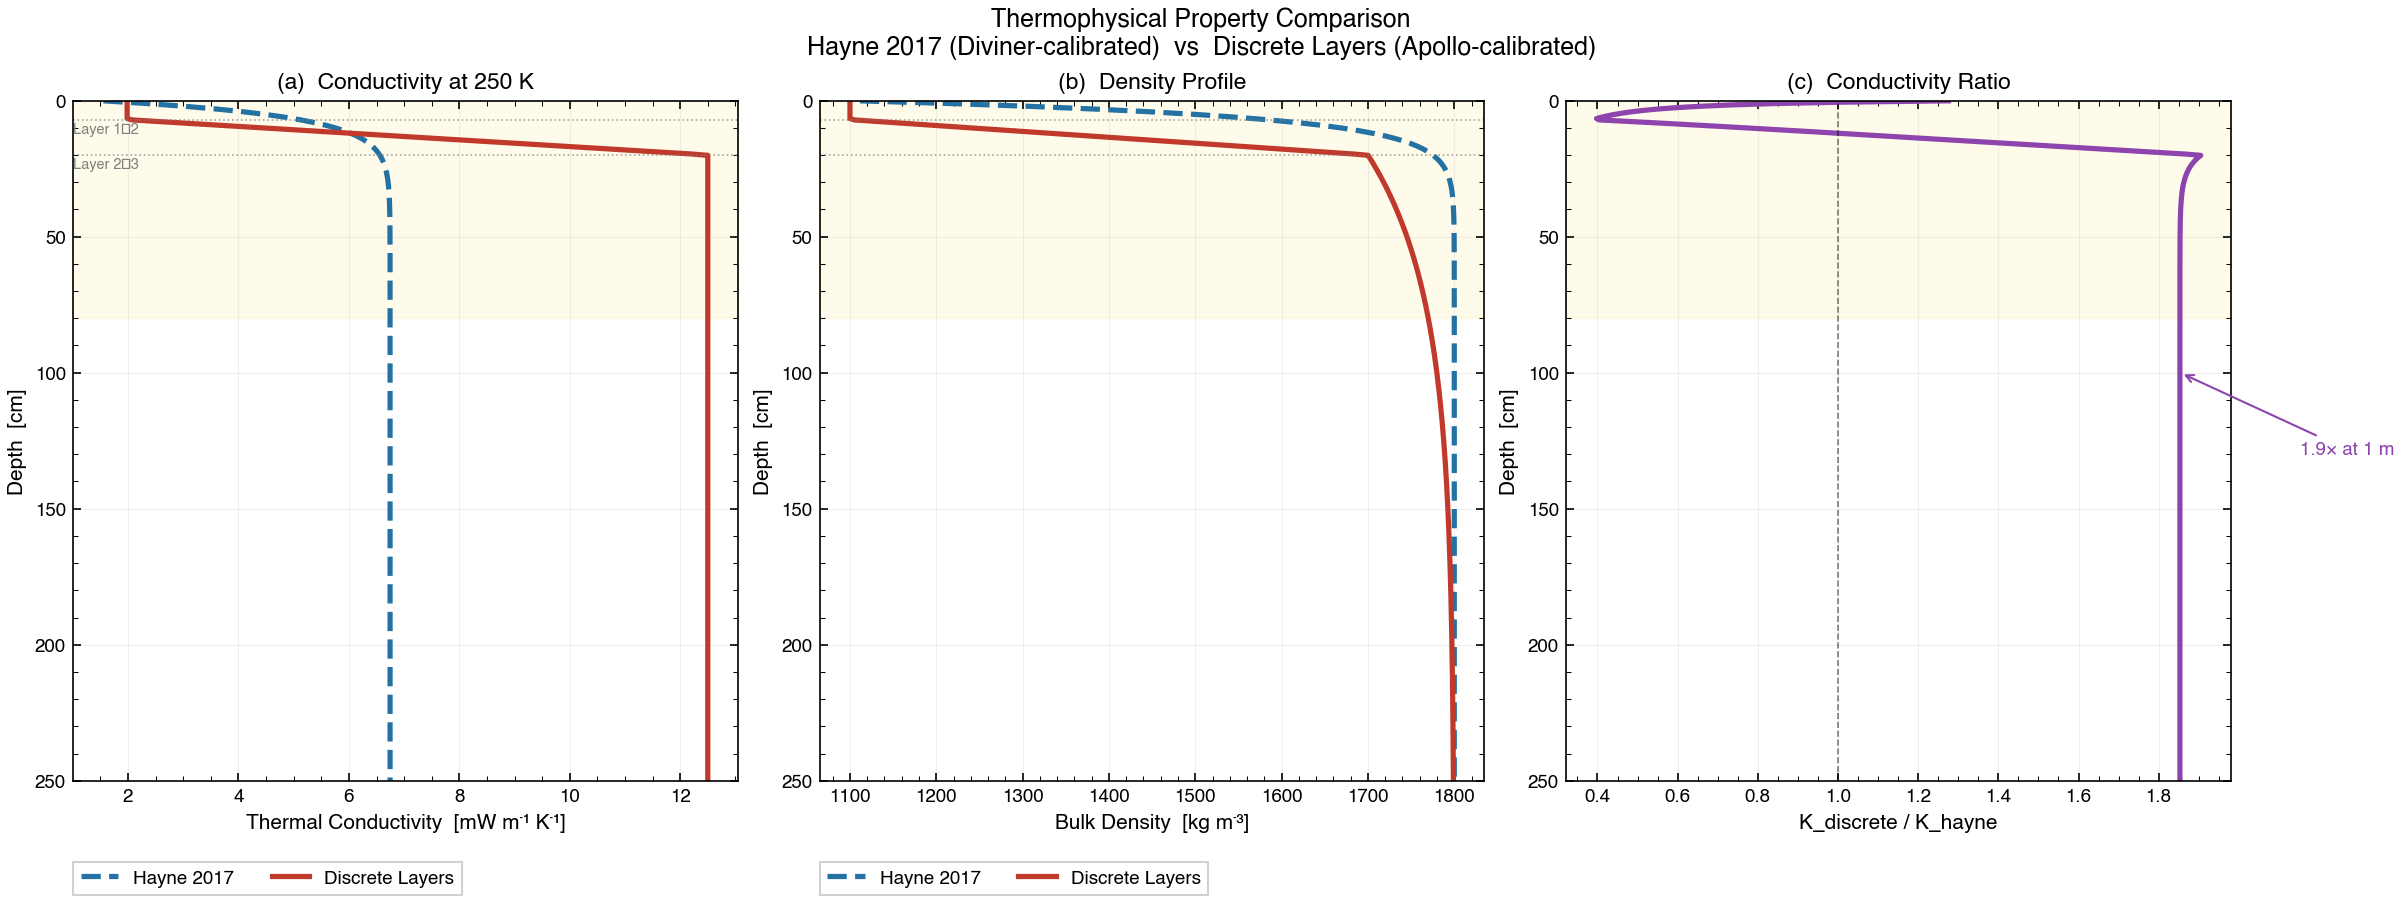

In [ ]:
# ===================================================================
# Property comparison: Hayne (2017) vs Discrete Layers
# Lunar-Clean style — deep red for Discrete, deep blue for Hayne
# ===================================================================

CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red

z_plot_prop = np.linspace(0.001, 2.5, 500)   # m
T_const = np.full_like(z_plot_prop, 250.0)    # K — representative T

# Compute properties at all depths
K_hayne_prop = conductivity_hayne(T_const, z_plot_prop)
K_disc_prop  = k_discrete(T_const, z_plot_prop)
rho_hayne_prop = density_hayne(z_plot_prop)
rho_disc_prop  = rho_discrete(z_plot_prop)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# ---- Panel A: Thermal conductivity ----
ax = axes[0]
ax.plot(K_hayne_prop * 1e3, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(K_disc_prop * 1e3, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

# Layer boundaries
for h_cm, lbl in [(H_LAYER1*100, 'Layer 1→2'), (H_LAYER2*100, 'Layer 2→3')]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 0.1, h_cm + 1,
            lbl, fontsize=7, color='gray', va='top')

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Thermal Conductivity  [mW m⁻¹ K⁻¹]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(a)  Conductivity at 250 K', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel B: Density ----
ax = axes[1]
ax.plot(rho_hayne_prop, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(rho_disc_prop, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

for h_cm in [H_LAYER1*100, H_LAYER2*100]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Bulk Density  [kg m⁻³]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Density Profile', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel C: Conductivity ratio ----
ax = axes[2]
ratio = K_disc_prop / K_hayne_prop
ax.plot(ratio, z_plot_prop * 100, color='#8E44AD', lw=2.5)
ax.axvline(1.0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('K_discrete / K_hayne', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(c)  Conductivity Ratio', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.grid(True, alpha=0.2)

# Annotate the deep ratio
iz_1m = np.argmin(np.abs(z_plot_prop - 1.0))
ax.annotate(f'{ratio[iz_1m]:.1f}× at 1 m', xy=(ratio[iz_1m], 100),
            fontsize=9, color='#8E44AD', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8E44AD'),
            xytext=(ratio[iz_1m]+0.3, 130))

fig.suptitle('Thermophysical Property Comparison\n'
             'Hayne 2017 (Diviner-calibrated)  vs  Discrete Layers (Apollo-calibrated)',
             fontsize=12, weight='bold')
plt.show()

## 3  Model vs Observation

Three figures:

1. **Hayne 2017 only** — profile + residuals + statistics
2. **Discrete Layers only** — profile + residuals + statistics
3. **Both models together** — overlaid profiles + dual residuals + head-to-head statistics

────────────────────────────────────────────────────────────
Figure 3a: Hayne 2017 only


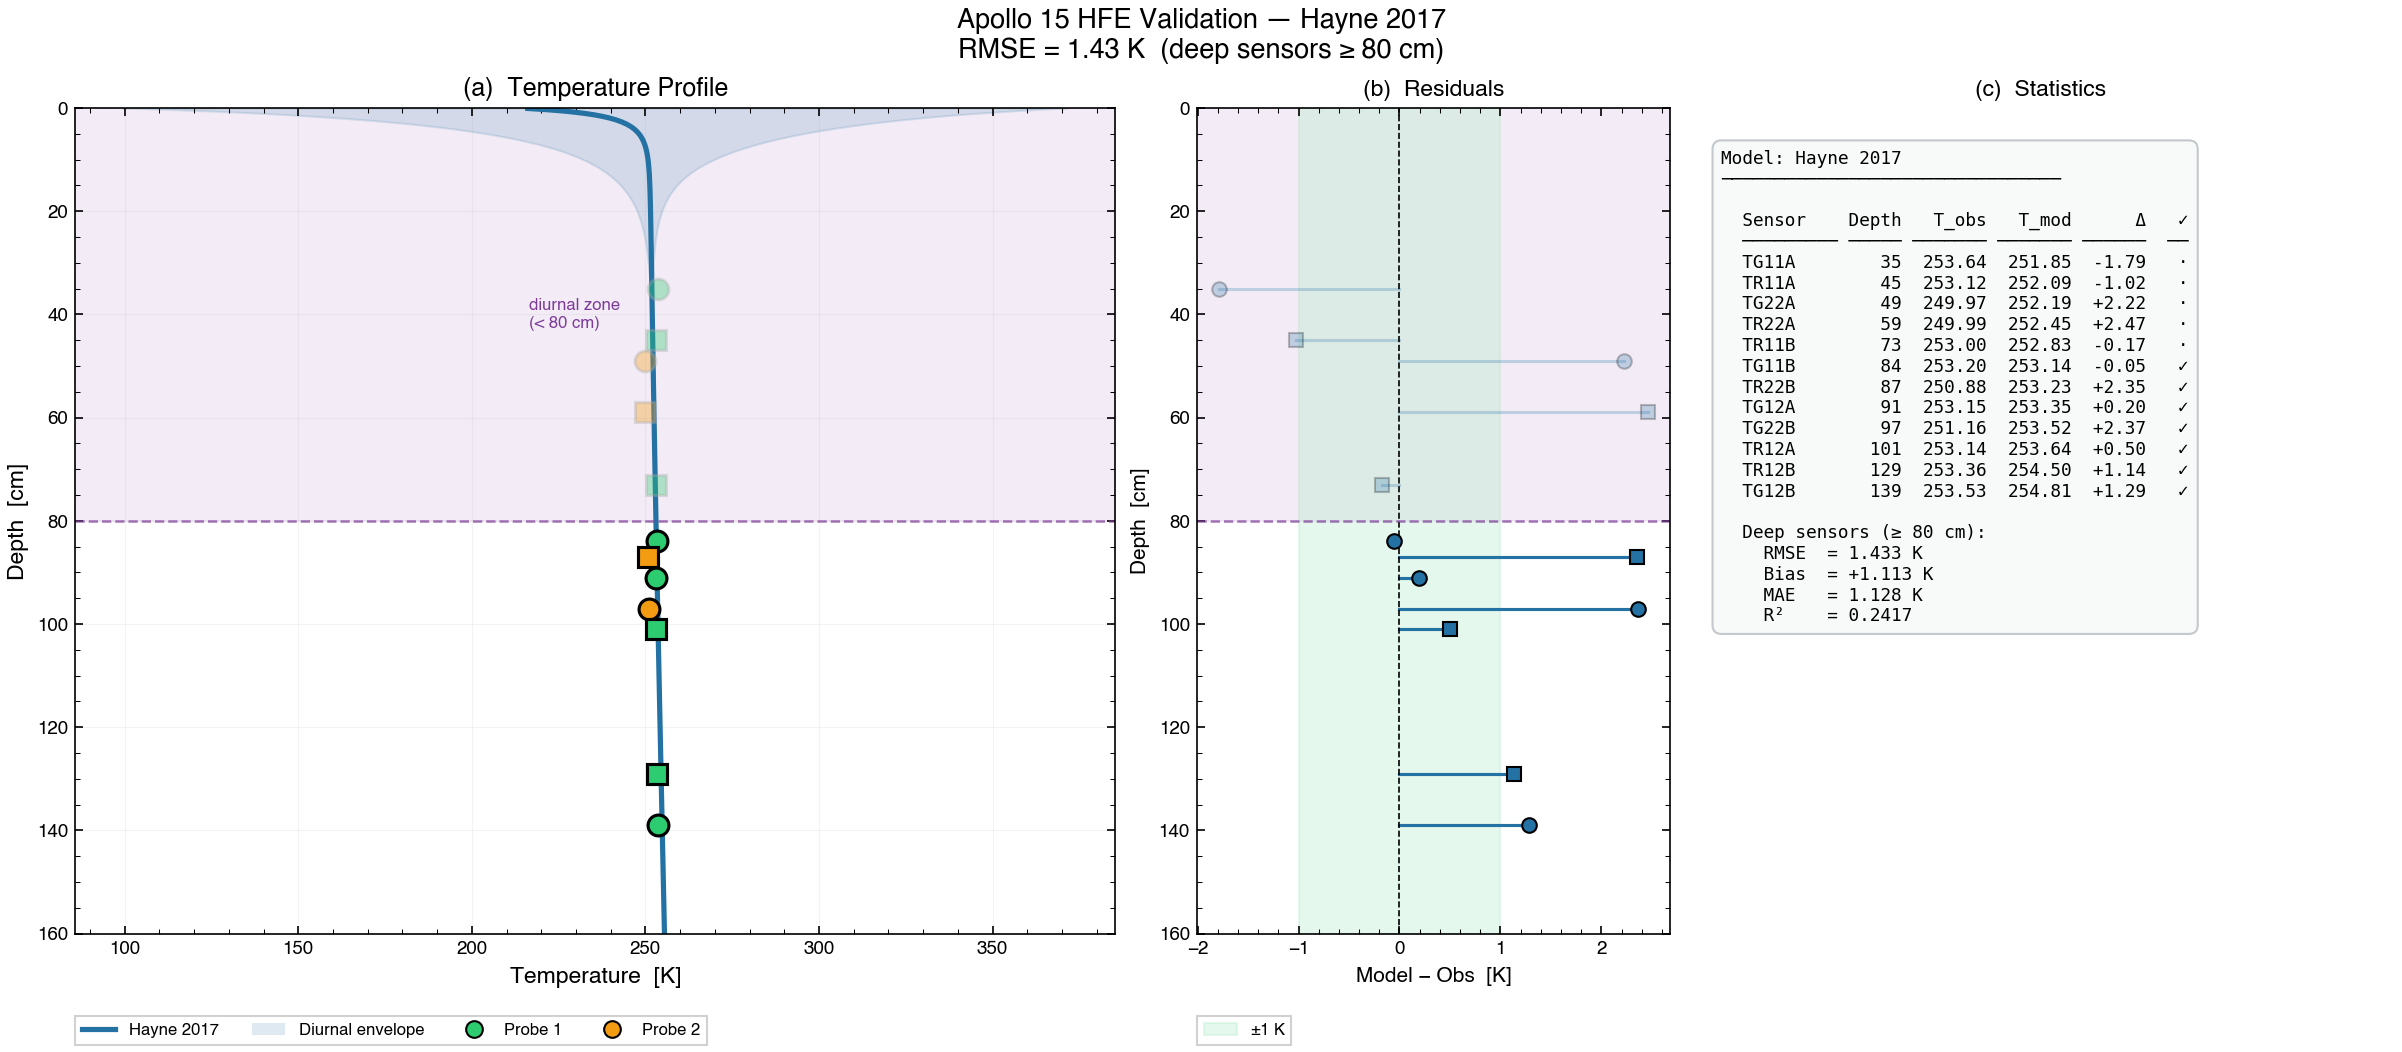

────────────────────────────────────────────────────────────
Figure 3b: Discrete Layers only


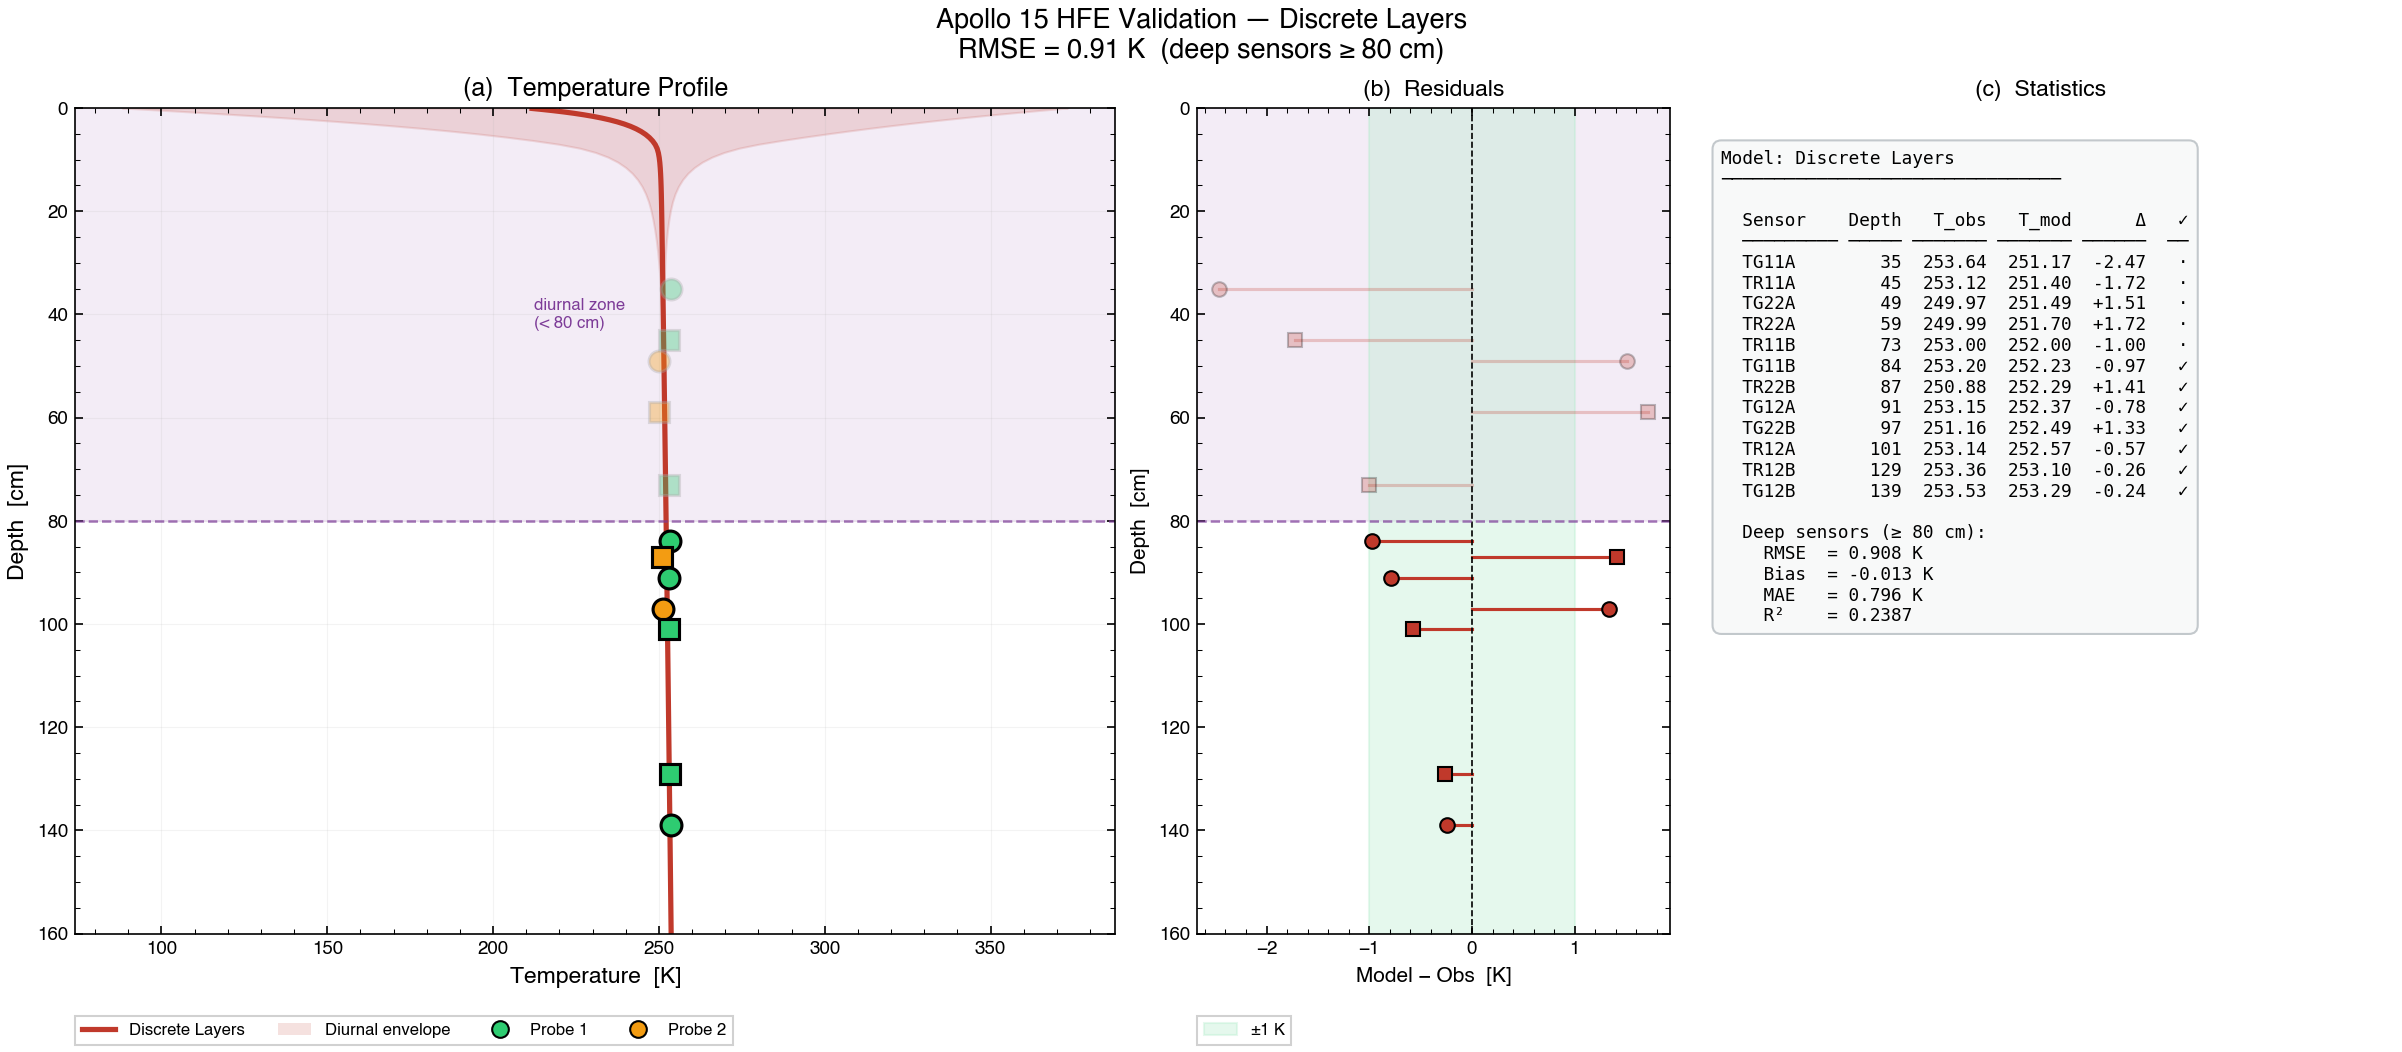

────────────────────────────────────────────────────────────
Figure 3c: Both models together


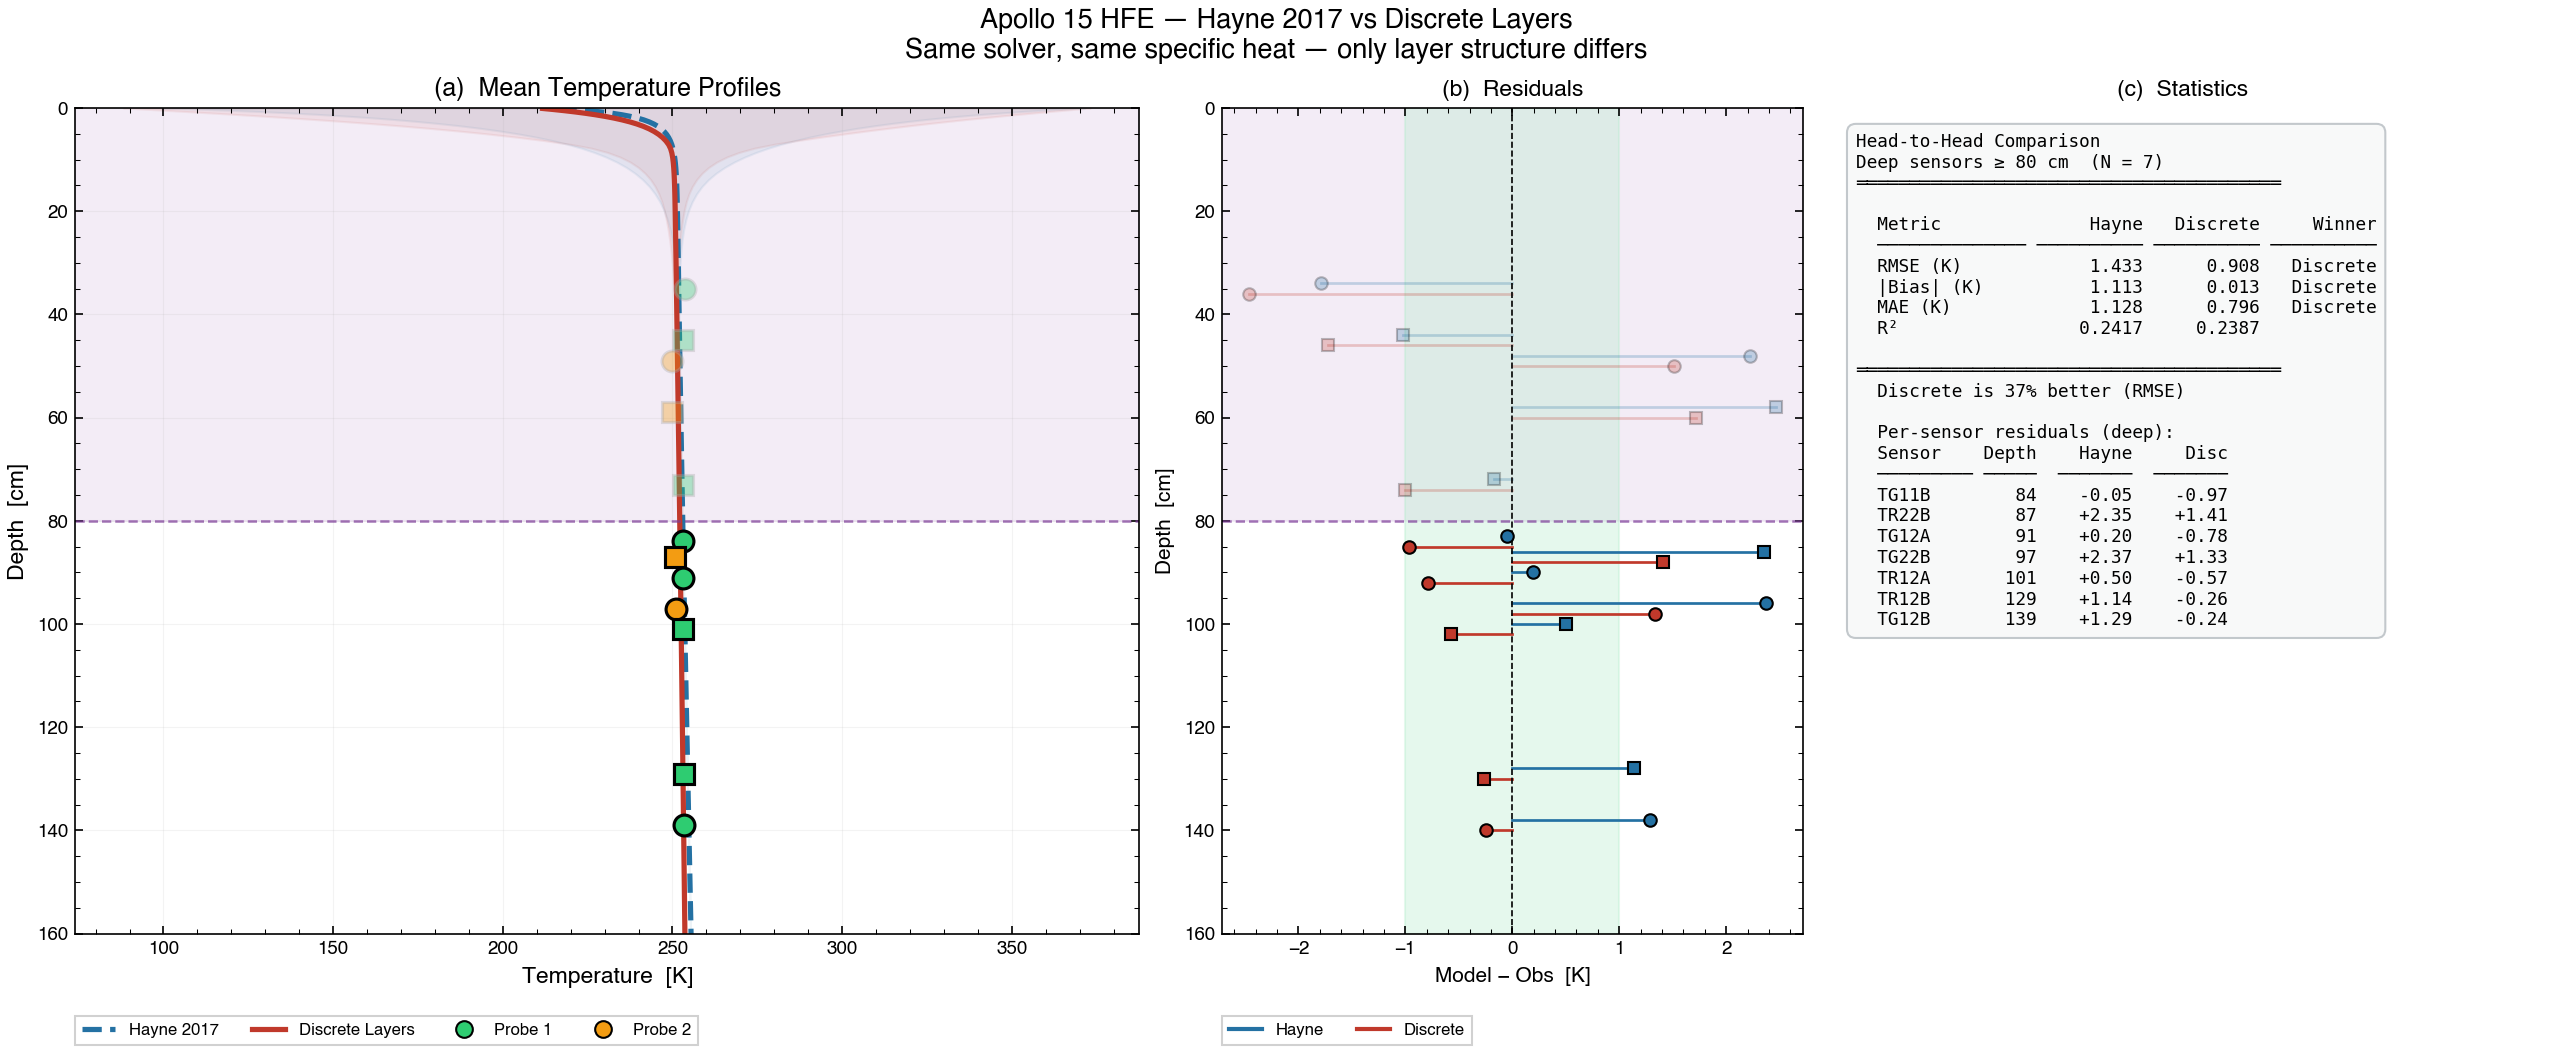

In [ ]:
# ===================================================================
# Model vs Observation — three figures
# ===================================================================
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# --- Shared colours ---
CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red
ZONE_CLR  = '#E8DAEF'    # soft lavender for diurnal zone (replaces gold)
ZONE_LINE = '#7D3C98'    # purple line at boundary

# --- Precompute everything ---
T_mean_hayne = out.T.mean(axis=1)
T_mean_disc  = out_disc.T.mean(axis=1)

T_hayne_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_hayne)
T_disc_at_sensor  = np.interp(depth_cm_all, z_cm_model, T_mean_disc)

resid_hayne_all = T_hayne_at_sensor - T_eq_all
resid_disc_all  = T_disc_at_sensor  - T_eq_all
resid_hayne_deep = resid_hayne_all[deep_mask]
resid_disc_deep  = resid_disc_all[deep_mask]

rmse_hayne_deep = np.sqrt(np.mean(resid_hayne_deep**2))
bias_hayne_deep = np.mean(resid_hayne_deep)
mae_hayne_deep  = np.mean(np.abs(resid_hayne_deep))
r_hayne_deep, _ = pearsonr(T_eq_deep, T_hayne_at_sensor[deep_mask])

rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
bias_disc_deep = np.mean(resid_disc_deep)
mae_disc_deep  = np.mean(np.abs(resid_disc_deep))
r_disc_deep, _ = pearsonr(T_eq_deep, T_disc_at_sensor[deep_mask])


# ===================================================================
# Helper: single-model figure (profile + residuals + stats text)
# ===================================================================
def plot_single_model(model_name, out_m, T_mean_m, T_at_sensor, resid_all,
                      resid_deep, color, rmse_d, bias_d, mae_d, r2_d):
    fig, axes = plt.subplots(1, 3, figsize=(16, 7),
                              gridspec_kw={'width_ratios': [2.2, 1, 1.5]},
                              constrained_layout=True)

    # ---- Panel A: Temperature profile ----
    ax = axes[0]
    T_max_m = out_m.T.max(axis=1)
    T_min_m = out_m.T.min(axis=1)
    ax.fill_betweenx(z_cm_model, T_min_m, T_max_m,
                      alpha=0.15, color=color, label='Diurnal envelope')
    ax.plot(T_mean_m, z_cm_model, color=color, lw=2.5, label=f'{model_name} (mean)')

    for i, s in enumerate(sensors_all):
        marker = 'o' if s['stype'] == 'TG' else 's'
        fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
        ec = 'k' if deep_mask[i] else '#AAAAAA'
        alpha_s = 1.0 if deep_mask[i] else 0.35
        ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
                mew=1.5, zorder=5, alpha=alpha_s)

    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.text(T_mean_m.min()+0.5, MIN_DEPTH_CM/2,
            f'diurnal zone\n(< {MIN_DEPTH_CM} cm)', fontsize=8,
            ha='left', va='center', color=ZONE_LINE, style='italic')

    handles = [
        Line2D([0],[0], color=color, lw=2.5, label=f'{model_name}'),
        plt.Rectangle((0,0),1,1, fc=color, alpha=0.15, label='Diurnal envelope'),
        Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
        Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
    ax.set_xlabel('Temperature  [K]', fontsize=11)
    ax.set_ylabel('Depth  [cm]', fontsize=11)
    ax.set_title('(a)  Temperature Profile', fontsize=12, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.grid(True, alpha=0.15)

    # ---- Panel B: Residuals ----
    ax = axes[1]
    for i, s in enumerate(sensors_all):
        alpha_s = 1.0 if deep_mask[i] else 0.25
        marker = 'o' if s['stype'] == 'TG' else 's'
        ax.plot([0, resid_all[i]], [s['depth_cm']]*2, '-',
                color=color, alpha=alpha_s, lw=1.5)
        ax.plot(resid_all[i], s['depth_cm'], marker, ms=7,
                mfc=color, mec='k', alpha=alpha_s, zorder=5)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.set_xlabel('Model − Obs  [K]', fontsize=10)
    ax.set_ylabel('Depth  [cm]', fontsize=10)
    ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.legend(fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), borderaxespad=0.0)

    # ---- Panel C: Stats text ----
    ax = axes[2]
    ax.axis('off')

    lines = []
    lines.append(f'Model: {model_name}')
    lines.append(f'─' * 32)
    lines.append(f'')
    lines.append(f'  {"Sensor":<9} {"Depth":>5} {"T_obs":>7} {"T_mod":>7} {"Δ":>6}  {"✓":>2}')
    lines.append(f'  {"─"*9} {"─"*5} {"─"*7} {"─"*7} {"─"*6}  {"─"*2}')
    for i, s in enumerate(sensors_all):
        tag = '✓' if deep_mask[i] else '·'
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f} '
            f'{s["T_eq"]:>7.2f} {T_at_sensor[i]:>7.2f} '
            f'{resid_all[i]:>+6.2f}  {tag:>2}'
        )
    lines.append(f'')
    lines.append(f'  Deep sensors (≥ {MIN_DEPTH_CM} cm):')
    lines.append(f'    RMSE  = {rmse_d:.3f} K')
    lines.append(f'    Bias  = {bias_d:+.3f} K')
    lines.append(f'    MAE   = {mae_d:.3f} K')
    lines.append(f'    R²    = {r2_d:.4f}')

    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=8.5, fontfamily='monospace', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                      edgecolor='#BDC3C7', alpha=0.9))
    ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

    fig.suptitle(f'Apollo 15 HFE Validation — {model_name}\n'
                 f'RMSE = {rmse_d:.2f} K  (deep sensors ≥ {MIN_DEPTH_CM} cm)',
                 fontsize=13, weight='bold')
    plt.show()


# ===================================================================
# Figure 3a: Hayne only
# ===================================================================
print('─' * 60)
print('Figure 3a: Hayne 2017 only')
plot_single_model('Hayne 2017', out, T_mean_hayne, T_hayne_at_sensor,
                  resid_hayne_all, resid_hayne_deep, CLR_HAYNE,
                  rmse_hayne_deep, bias_hayne_deep, mae_hayne_deep,
                  r_hayne_deep**2)

# ===================================================================
# Figure 3b: Discrete only
# ===================================================================
print('─' * 60)
print('Figure 3b: Discrete Layers only')
plot_single_model('Discrete Layers', out_disc, T_mean_disc, T_disc_at_sensor,
                  resid_disc_all, resid_disc_deep, CLR_DISC,
                  rmse_disc_deep, bias_disc_deep, mae_disc_deep,
                  r_disc_deep**2)


# ===================================================================
# Figure 3c: Both models together
# ===================================================================
print('─' * 60)
print('Figure 3c: Both models together')

fig, axes = plt.subplots(1, 3, figsize=(17, 7),
                          gridspec_kw={'width_ratios': [2.2, 1.2, 1.5]},
                          constrained_layout=True)

# ---- Panel A: Overlaid profiles ----
ax = axes[0]
# Envelopes
T_max_h = out.T.max(axis=1);      T_min_h = out.T.min(axis=1)
T_max_d = out_disc.T.max(axis=1);  T_min_d = out_disc.T.min(axis=1)
ax.fill_betweenx(z_cm_model, T_min_h, T_max_h, alpha=0.08, color=CLR_HAYNE)
ax.fill_betweenx(z_cm_model, T_min_d, T_max_d, alpha=0.08, color=CLR_DISC)
ax.plot(T_mean_hayne, z_cm_model, color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017')
ax.plot(T_mean_disc,  z_cm_model, color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers')

for i, s in enumerate(sensors_all):
    marker = 'o' if s['stype'] == 'TG' else 's'
    fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
    ec = 'k' if deep_mask[i] else '#AAAAAA'
    alpha_s = 1.0 if deep_mask[i] else 0.35
    ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
            mew=1.5, zorder=5, alpha=alpha_s)

handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017'),
    Line2D([0],[0], color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers'),
    Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
    Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Temperature  [K]', fontsize=11)
ax.set_ylabel('Depth  [cm]', fontsize=11)
ax.set_title('(a)  Mean Temperature Profiles', fontsize=12, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)
ax.grid(True, alpha=0.15)

# ---- Panel B: Dual residuals ----
ax = axes[1]
offset = 1.0
for i, s in enumerate(sensors_all):
    alpha_s = 1.0 if deep_mask[i] else 0.25
    marker = 'o' if s['stype'] == 'TG' else 's'
    d_cm = s['depth_cm']
    # Hayne
    ax.plot([0, resid_hayne_all[i]], [d_cm - offset]*2, '-',
            color=CLR_HAYNE, alpha=alpha_s, lw=1.3)
    ax.plot(resid_hayne_all[i], d_cm - offset, marker, ms=6,
            mfc=CLR_HAYNE, mec='k', alpha=alpha_s, zorder=5)
    # Discrete
    ax.plot([0, resid_disc_all[i]], [d_cm + offset]*2, '-',
            color=CLR_DISC, alpha=alpha_s, lw=1.3)
    ax.plot(resid_disc_all[i], d_cm + offset, marker, ms=6,
            mfc=CLR_DISC, mec='k', alpha=alpha_s, zorder=5)

ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
res_handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2, label='Hayne'),
    Line2D([0],[0], color=CLR_DISC, lw=2, label='Discrete'),
]
ax.legend(handles=res_handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=2, borderaxespad=0.0)
ax.set_xlabel('Model − Obs  [K]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)

# ---- Panel C: Head-to-head stats ----
ax = axes[2]
ax.axis('off')

lines = []
lines.append(f'Head-to-Head Comparison')
lines.append(f'Deep sensors ≥ {MIN_DEPTH_CM} cm  (N = {deep_mask.sum()})')
lines.append(f'{"═"*40}')
lines.append(f'')
lines.append(f'  {"Metric":<14} {"Hayne":>10} {"Discrete":>10} {"Winner":>10}')
lines.append(f'  {"─"*14} {"─"*10} {"─"*10} {"─"*10}')
for label, vh, vd in [
    ('RMSE (K)', rmse_hayne_deep, rmse_disc_deep),
    ('|Bias| (K)', abs(bias_hayne_deep), abs(bias_disc_deep)),
    ('MAE (K)', mae_hayne_deep, mae_disc_deep),
]:
    w = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
    lines.append(f'  {label:<14} {vh:>10.3f} {vd:>10.3f} {w:>10}')
lines.append(f'  {"R²":<14} {r_hayne_deep**2:>10.4f} {r_disc_deep**2:>10.4f}')

lines.append(f'')
lines.append(f'{"═"*40}')
pct = (1 - rmse_disc_deep / rmse_hayne_deep) * 100
lines.append(f'  Discrete is {pct:.0f}% better (RMSE)')
lines.append(f'')
lines.append(f'  Per-sensor residuals (deep):')
lines.append(f'  {"Sensor":<9} {"Depth":>5}  {"Hayne":>7}  {"Disc":>7}')
lines.append(f'  {"─"*9} {"─"*5}  {"─"*7}  {"─"*7}')
for i, s in enumerate(sensors_all):
    if deep_mask[i]:
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f}  '
            f'{resid_hayne_all[i]:>+7.2f}  {resid_disc_all[i]:>+7.2f}'
        )

ax.text(0.05, 0.97, '\n'.join(lines), transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                  edgecolor='#BDC3C7', alpha=0.9))
ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

fig.suptitle('Apollo 15 HFE — Hayne 2017 vs Discrete Layers\n'
             'Same solver, same specific heat — only layer structure differs',
             fontsize=13, weight='bold')
plt.show()

## 4  Diurnal Temperature Cycles  —  Model Comparison

Diurnal temperature variation at selected depths for both models.  The discrete
model's higher deep conductivity leads to faster thermal-wave propagation and
a different amplitude decay profile.  Below ~80 cm the diurnal signal is
negligible in both models — confirming these sensors measure the steady-state
geothermal gradient.

  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/a15_diurnal_cycles.pdf
  Saved: /Users/rp3gregorio/Documents/Lunar-V2/output/figures/a15_diurnal_cycles.png


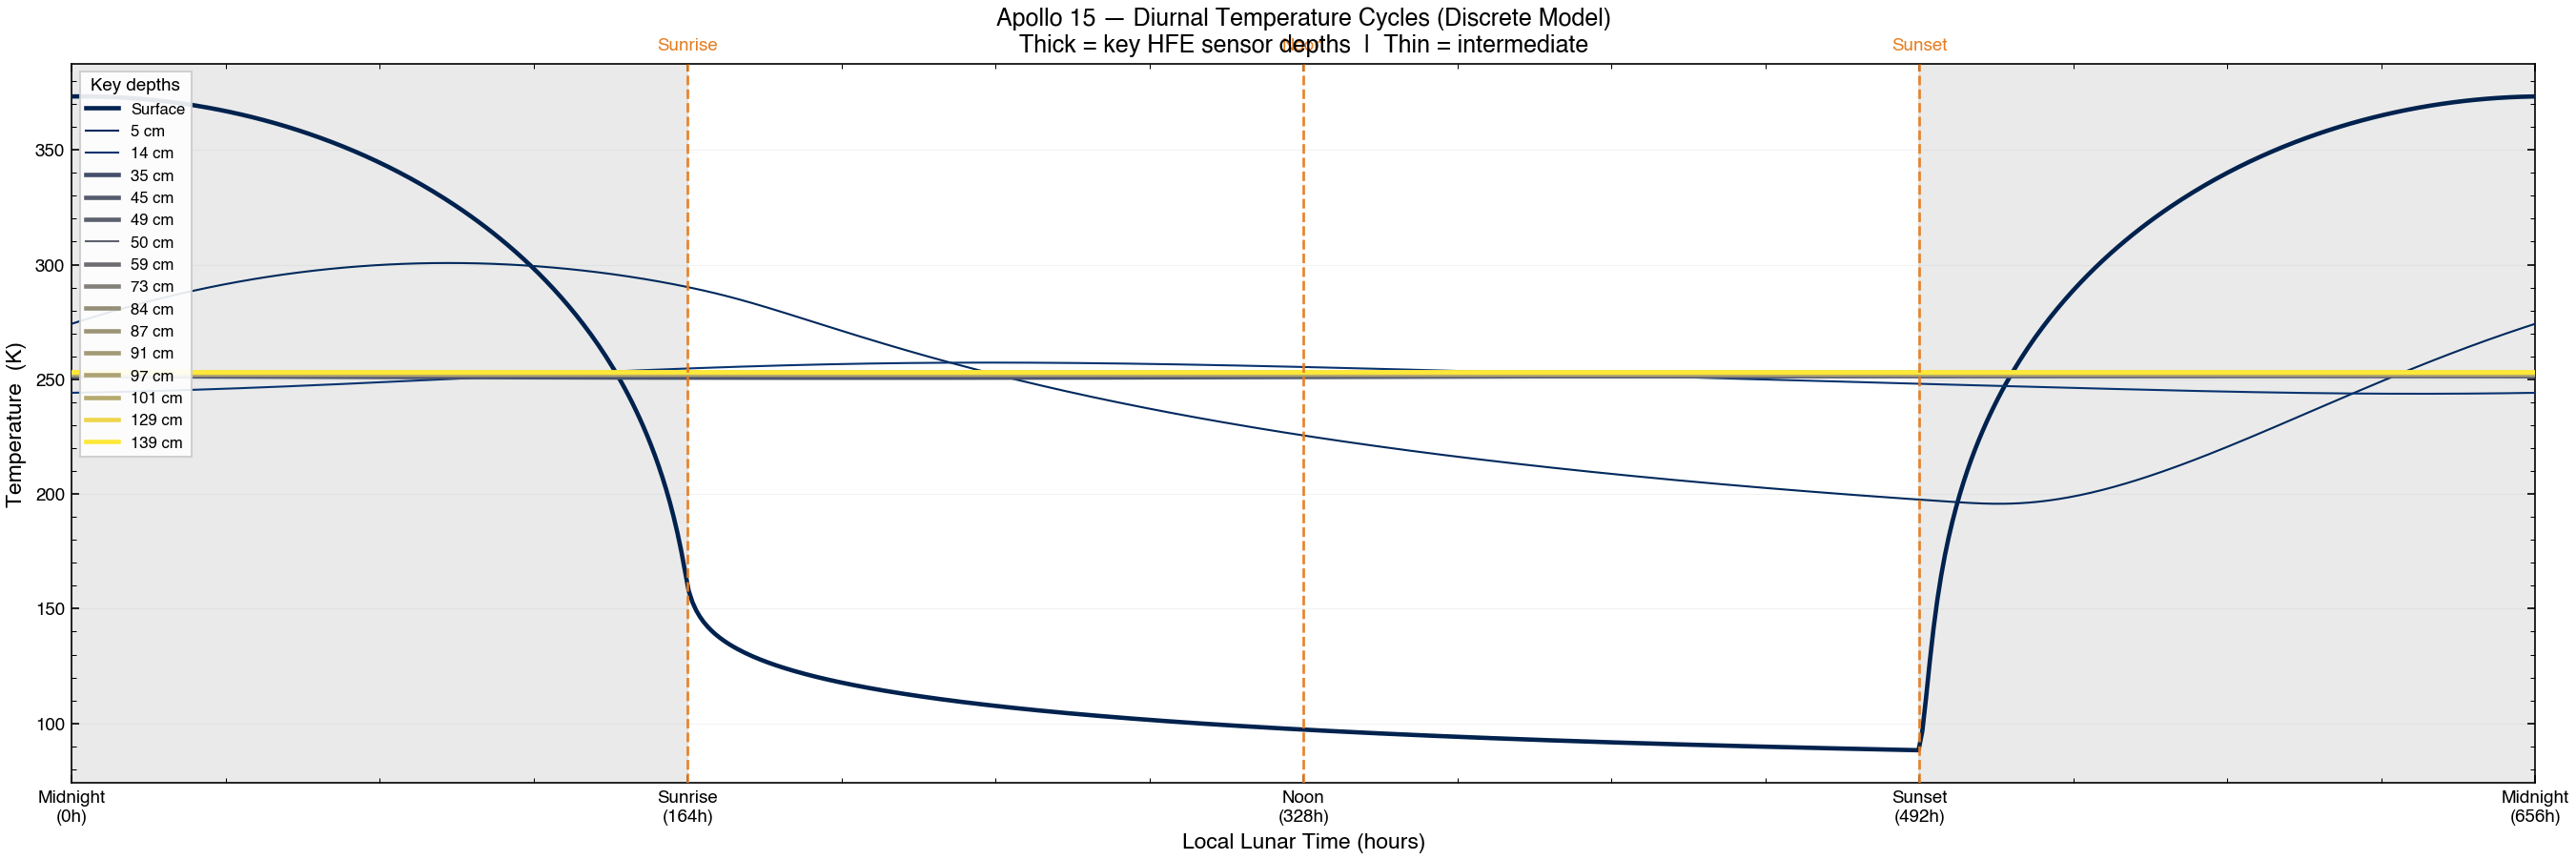

In [ ]:
# ===================================================================
# Diurnal Temperature Cycles — Apollo 15 Discrete Model
# Reference format: single wide panel, actual lunar-time x-axis,
# depth-coloured curves (dark = surface, light = deep),
# night shading, Sunrise / Noon / Sunset markers.
# ===================================================================

# ---- depths to plot ----
hfe_depths_cm   = sorted(set(round(s['depth_cm']) for s in sensors_all))
intermediate_cm = [0, 5, 14, 50]
all_plot_cm     = sorted(set(intermediate_cm + hfe_depths_cm))
key_depths      = set([0] + hfe_depths_cm)   # thick lines

# ---- colormap: surface = dark, deep = light ----
_depth_max = max(all_plot_cm)
_cmap_dc   = plt.get_cmap('cividis')
_norm_dc   = plt.Normalize(vmin=0, vmax=_depth_max)

# ---- timing ----
T_hr        = T_LUNAR / 3600.0
_time_hr    = t_s / 3600.0
_sunrise_hr = T_hr / 4.0
_noon_hr    = T_hr / 2.0
_sunset_hr  = 3.0 * T_hr / 4.0

fig_dc, ax_dc = plt.subplots(figsize=(18, 6), constrained_layout=True)

# night shading
ax_dc.axvspan(0,          _sunrise_hr, color='#e8e8e8', alpha=0.90, zorder=0)
ax_dc.axvspan(_sunset_hr, T_hr,        color='#e8e8e8', alpha=0.90, zorder=0)

# depth curves
for _d_cm in all_plot_cm:
    _iz  = np.argmin(np.abs(z_cm_model - _d_cm))
    _clr = _cmap_dc(_norm_dc(_d_cm))
    _lw  = 2.2 if _d_cm in key_depths else 1.0
    _lbl = 'Surface' if _d_cm == 0 else f'{_d_cm} cm'
    ax_dc.plot(_time_hr, out_disc.T[_iz, :], color=_clr, lw=_lw,
               label=_lbl, zorder=3)

# Sunrise / Noon / Sunset vertical lines + top labels
for _hr, _evtlbl in [(_sunrise_hr, 'Sunrise'), (_noon_hr, 'Noon'), (_sunset_hr, 'Sunset')]:
    ax_dc.axvline(_hr, color='#E67E22', lw=1.3, ls='--', alpha=0.95, zorder=4)
    ax_dc.annotate(_evtlbl,
                   xy=(_hr, 1.0), xycoords=('data', 'axes fraction'),
                   ha='center', va='bottom', fontsize=9,
                   color='#E67E22', fontweight='bold',
                   xytext=(0, 5), textcoords='offset points')

# x-axis ticks
ax_dc.set_xticks([0, _sunrise_hr, _noon_hr, _sunset_hr, T_hr])
ax_dc.set_xticklabels([
    f'Midnight\n(0h)',
    f'Sunrise\n({_sunrise_hr:.0f}h)',
    f'Noon\n({_noon_hr:.0f}h)',
    f'Sunset\n({_sunset_hr:.0f}h)',
    f'Midnight\n({T_hr:.0f}h)',
], fontsize=9)

ax_dc.set_xlim(0, T_hr)
ax_dc.set_xlabel('Local Lunar Time (hours)', fontsize=11)
ax_dc.set_ylabel('Temperature  (K)', fontsize=11)
ax_dc.set_title(
    f'Apollo 15 — Diurnal Temperature Cycles (Discrete Model)\n'
    f'Thick = key HFE sensor depths  |  Thin = intermediate',
    fontsize=12, weight='bold'
)
ax_dc.legend(loc='upper left', fontsize=8, title='Key depths',
             title_fontsize=9, framealpha=0.9, ncol=1)
ax_dc.grid(True, alpha=0.15)

save_figure(fig_dc, 'a15_diurnal_cycles', output_dir=OUTPUT_DIR)
plt.show()


## 4B  Per-Sensor Diurnal Grid — Model vs Apollo HFE

One panel per sensor, sorted by depth.  X-axis is **Local Solar Time** (LST)
derived from phase-folding the model output so that midnight = LST 0 / 24 h,
sunrise ≈ 6 h, noon ≈ 12 h, sunset ≈ 18 h.  Apollo observations are
phase-folded with the same lunation period and then cross-correlated to the
model at the 35 cm sensor to find the best LST alignment offset.

Gray shading = lunar night.  Orange dotted line = Apollo equilibrium mean T.
This is the primary diagnostic for identifying the **thermal stability region**:
below ~80 cm the diurnal amplitude collapses to < 0.1 K and the sensor traces
the geothermal gradient, not the surface forcing.

In [ ]:
# ===================================================================
# Per-Sensor Diurnal Grid — Model vs Apollo HFE (LST x-axis)
# Phase-fold Apollo data using the SYNODIC period (true solar day),
# cross-correlate at a shallow sensor, then overlay binned medians.
# ===================================================================

# ---- 1. Convert model time → Local Solar Time [0, 24 hr] ----
# Sinusoidal forcing: insolation peak at t=0, so noon = 0.
# Shift by half-period so LST 0 = midnight.
lst_model_hr = ((t_s - T_LUNAR / 2.0) % T_LUNAR) / T_LUNAR * 24.0
sort_idx     = np.argsort(lst_model_hr)
lst_sorted   = lst_model_hr[sort_idx]

# ---- 2. Phase-fold Apollo observations using synodic period ----
# The sidereal period (27.32 d) drives the MODEL insolation, but the
# OBSERVED day/night cycle repeats at the synodic period (29.53 d).
# Folding with the sidereal period mis-phases successive lunations,
# producing multiple shifted copies of the diurnal curve.
T_SYNODIC = 29.530589 * 86400.0   # Moon synodic period [s]

def _phase_fold(dtab, T_syn):
    """Return {sensor_name: (lst_hr, T_K)} for every sensor in dtab."""
    result = {}
    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        t_unix = iso_to_seconds(subset['time_iso'])
        T_obs  = subset['T'].astype(np.float64)
        good   = np.isfinite(T_obs) & (T_obs > 50.0)
        t_unix, T_obs = t_unix[good], T_obs[good]
        if len(t_unix) < 10:
            continue
        lst = (t_unix % T_syn) / T_syn * 24.0
        result[sensor.strip()] = (lst, T_obs)
    return result

obs_p1 = _phase_fold(d1, T_SYNODIC)
obs_p2 = _phase_fold(d2, T_SYNODIC)
obs_all = {**obs_p1, **obs_p2}

# ---- 3. Cross-correlate at 35 cm to find LST alignment offset ----
REF_SENSOR   = 'TG11A'
REF_DEPTH_CM = 35.0
N_BINS       = 72   # 20-min bins

iz_ref      = np.argmin(np.abs(z_cm_model - REF_DEPTH_CM))
T_model_ref = out.T[iz_ref, sort_idx]
bin_edges   = np.linspace(0, 24, N_BINS + 1)
bin_ctr     = 0.5 * (bin_edges[:-1] + bin_edges[1:])
T_model_binned = np.array([
    np.mean(T_model_ref[(lst_sorted >= bin_edges[k]) & (lst_sorted < bin_edges[k+1])])
    if np.any((lst_sorted >= bin_edges[k]) & (lst_sorted < bin_edges[k+1])) else np.nan
    for k in range(N_BINS)
])

best_offset_hr = 0.0
best_corr      = -np.inf
if REF_SENSOR in obs_all:
    _lst, _T = obs_all[REF_SENSOR]
    n_half = len(_lst) // 2
    _lst, _T = _lst[n_half:], _T[n_half:]
    for shift_idx in range(N_BINS):
        shift_hr  = shift_idx * 24.0 / N_BINS
        lst_shift = (_lst + shift_hr) % 24.0
        T_binned_obs = np.array([
            np.mean(_T[(lst_shift >= bin_edges[k]) & (lst_shift < bin_edges[k+1])])
            if np.any((lst_shift >= bin_edges[k]) & (lst_shift < bin_edges[k+1])) else np.nan
            for k in range(N_BINS)
        ])
        valid = np.isfinite(T_model_binned) & np.isfinite(T_binned_obs)
        if valid.sum() < 12:
            continue
        corr = np.corrcoef(T_model_binned[valid], T_binned_obs[valid])[0, 1]
        if corr > best_corr:
            best_corr      = corr
            best_offset_hr = shift_hr

best_offset_abs_hr = best_offset_hr / 24.0 * (T_SYNODIC / 3600.0)
print(f'LST alignment offset: +{best_offset_abs_hr:.1f} h  '
      f'(r = {best_corr:.3f} at {REF_DEPTH_CM:.0f} cm)')

# ---- 4. Filter to sensors with visible diurnal amplitude ----
sorted_sensors = sorted(sensors_all, key=lambda s: s['depth_cm'])
diurnal_sensors = [
    s for s in sorted_sensors
    if np.ptp(out_disc.T[np.argmin(np.abs(z_cm_model - s['depth_cm'])), :]) >= 0.05
]
n_sensors = len(diurnal_sensors)
if n_sensors == 0:
    diurnal_sensors = sorted_sensors[:6]
    n_sensors = len(diurnal_sensors)
print(f'Showing {n_sensors} sensors with diurnal amplitude >= 0.05 K')

NCOLS = 3
NROWS = int(np.ceil(n_sensors / NCOLS))

# Display colours
CLR_DISC_PLOT  = '#1565C0'  # blue solid
CLR_HAYNE_PLOT = '#E67E22'  # orange dashed
CLR_OBS        = '#1a1a2e'  # near-black
NIGHT_CLR      = '#ececec'  # light gray

fig, axes = plt.subplots(NROWS, NCOLS,
                          figsize=(14, NROWS * 2.8),
                          constrained_layout=True)
axes_flat = np.atleast_1d(axes).flatten()

for ax_idx, s in enumerate(diurnal_sensors):
    ax       = axes_flat[ax_idx]
    depth_cm = s['depth_cm']
    sensor   = s['sensor']
    iz       = np.argmin(np.abs(z_cm_model - depth_cm))

    # Night shading
    ax.axvspan(0, 6,   color=NIGHT_CLR, alpha=0.80, zorder=0)
    ax.axvspan(18, 24, color=NIGHT_CLR, alpha=0.80, zorder=0)

    # Discrete model (blue solid)
    ax.plot(lst_sorted, out_disc.T[iz, sort_idx],
            color=CLR_DISC_PLOT, lw=1.8, ls='-', zorder=3,
            label='Discrete')

    # Hayne 2017 model (orange dashed)
    ax.plot(lst_sorted, out.T[iz, sort_idx],
            color=CLR_HAYNE_PLOT, lw=1.4, ls='--', zorder=3,
            label='Hayne 2017')

    # Apollo — binned median with IQR envelope (one clean curve)
    if sensor in obs_all:
        lst_raw, T_obs_raw = obs_all[sensor]
        n_half = len(lst_raw) // 2
        lst_raw   = lst_raw[n_half:]
        T_obs_raw = T_obs_raw[n_half:]
        lst_aligned = (lst_raw + best_offset_hr) % 24.0
        obs_med = np.full(N_BINS, np.nan)
        obs_q25 = np.full(N_BINS, np.nan)
        obs_q75 = np.full(N_BINS, np.nan)
        for k in range(N_BINS):
            in_bin = (lst_aligned >= bin_edges[k]) & (lst_aligned < bin_edges[k+1])
            if in_bin.sum() >= 3:
                obs_med[k] = np.median(T_obs_raw[in_bin])
                obs_q25[k] = np.percentile(T_obs_raw[in_bin], 25)
                obs_q75[k] = np.percentile(T_obs_raw[in_bin], 75)
        ok = np.isfinite(obs_med)
        if ok.any():
            ax.fill_between(bin_ctr[ok], obs_q25[ok], obs_q75[ok],
                            color=CLR_OBS, alpha=0.12, zorder=2)
            ax.plot(bin_ctr[ok], obs_med[ok],
                    color=CLR_OBS, lw=1.4, zorder=4,
                    label='Apollo (median)')

    # Panel title
    title_clr = '#C0392B' if depth_cm < MIN_DEPTH_CM else '#1a1a2e'
    ax.set_title(f'{depth_cm:.0f} cm \u2014 {sensor}',
                 fontsize=9, weight='bold', color=title_clr)

    ax.set_xlim(0, 24)
    ax.set_xticks([0, 6, 12, 18, 24])
    ax.set_xticklabels(['Midnight', 'Sunrise', 'Noon', 'Sunset', 'Midnight'],
                        fontsize=7, rotation=30, ha='right')
    ax.tick_params(axis='y', labelsize=8)
    if ax_idx % NCOLS == 0:
        ax.set_ylabel('Temperature  (K)', fontsize=8)
    if ax_idx == 0:
        ax.legend(fontsize=7, loc='lower center',
                  ncol=3, framealpha=0.85)

# Hide unused axes
for ax_idx in range(n_sensors, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(
    f'Apollo 15 \u2014 Model vs Apollo HFE Diurnal Cycles\n'
    f'Apollo phase-folded at synodic period (29.53 d), '
    f'shifted +{best_offset_abs_hr:.1f} h '
    f'(cross-corr r={best_corr:.3f} at {REF_DEPTH_CM:.0f} cm)',
    fontsize=9, weight='bold'
)

save_figure(fig, 'diurnal_sensor_grid_lst', output_dir=OUTPUT_DIR)
plt.show()

## 5  Subsurface Temperature Heatmaps — Side by Side

Temperature as a function of depth and time for both models, plotted with the
same colour scale so differences are immediately visible.  The right panel
shows the **temperature difference** (Discrete − Hayne) to highlight where and
when the models diverge most.

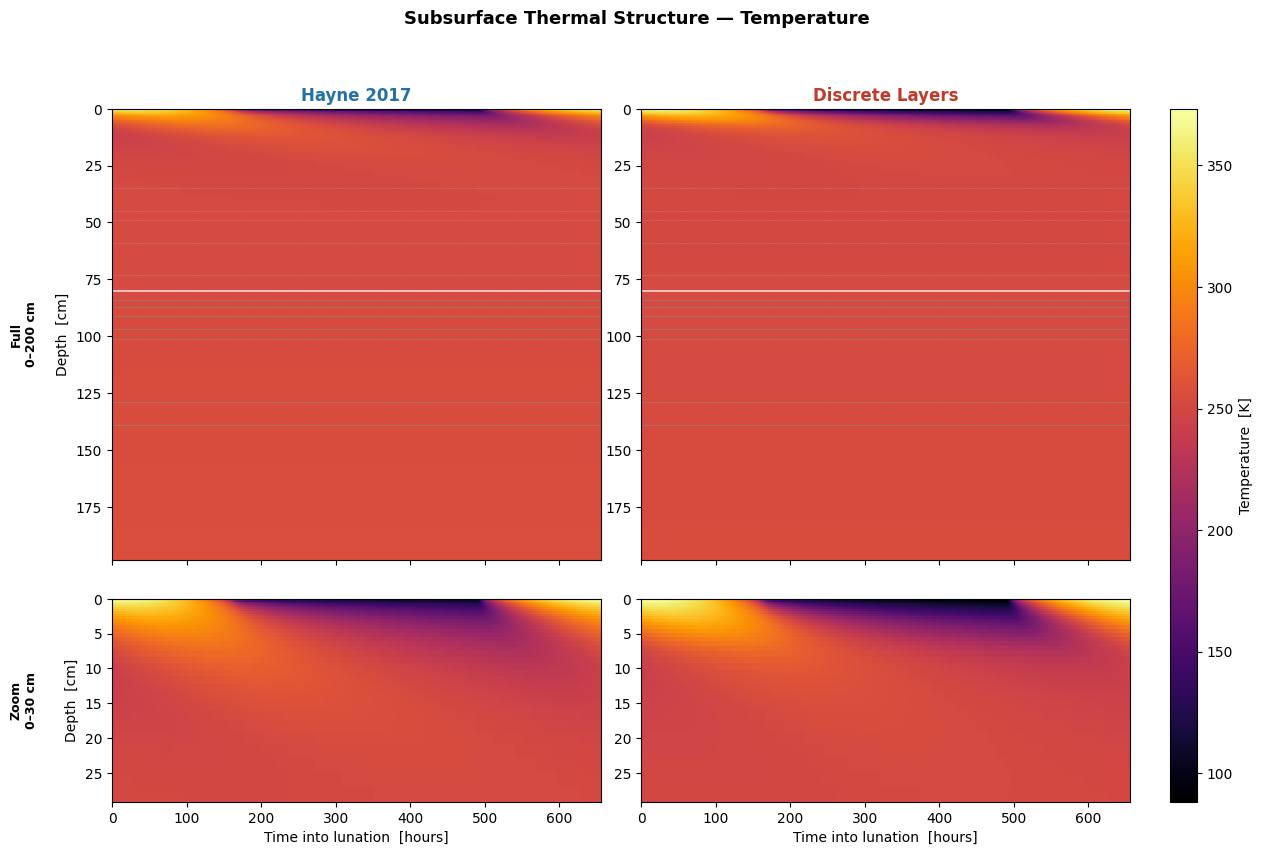

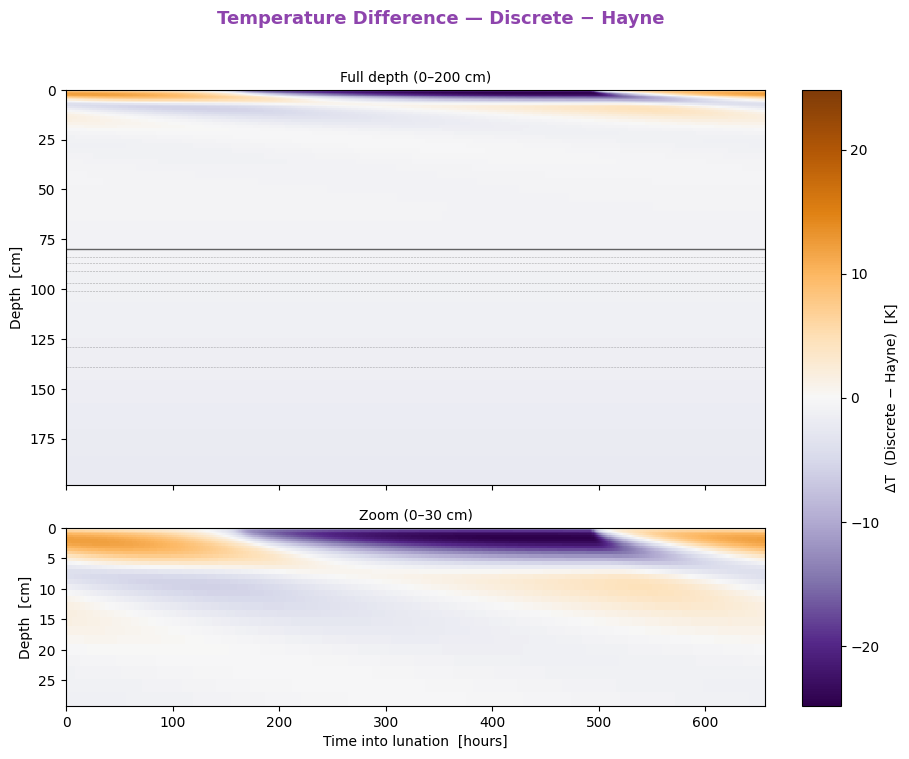

In [ ]:
# ===================================================================
# Subsurface heatmaps — Hayne vs Discrete
# Row 1: full depth (0–200 cm)   Row 2: zoomed (0–30 cm)
# Colorbars are drawn in dedicated side axes (never over data)
# ===================================================================
time_hr = t_s / 3600.0

depth_limit_cm = 200
zoom_limit_cm  = 30

mask_full = z_cm_model <= depth_limit_cm
mask_zoom = z_cm_model <= zoom_limit_cm
z_full = z_cm_model[mask_full]
z_zoom = z_cm_model[mask_zoom]

T_h_full = out.T[mask_full, :]
T_d_full = out_disc.T[mask_full, :]
T_diff_full = T_d_full - T_h_full

T_h_zoom = out.T[mask_zoom, :]
T_d_zoom = out_disc.T[mask_zoom, :]
T_diff_zoom = T_d_zoom - T_h_zoom

vmin = min(T_h_full.min(), T_d_full.min())
vmax = max(T_h_full.max(), T_d_full.max())
dT_abs = max(abs(T_diff_full.min()), abs(T_diff_full.max()))

# --- Figure 5a: Temperature heatmaps (Hayne + Discrete, full + zoom) ---
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[1.0, 1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.12,
    hspace=0.12,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
cax_temp = fig.add_subplot(gs[:, 2])

for col, (out_m, title, clr) in enumerate([
    (out, 'Hayne 2017', CLR_HAYNE),
    (out_disc, 'Discrete Layers', CLR_DISC),
]):
    # Full depth
    ax = axes[0, col]
    T_f = out_m.T[mask_full, :]
    im = ax.pcolormesh(time_hr, z_full, T_f, shading='auto',
                       cmap='inferno', vmin=vmin, vmax=vmax)
    for s_item in sensors_all:
        c = 'cyan' if s_item['depth_cm'] >= MIN_DEPTH_CM else '#BBBBBB'
        ax.axhline(s_item['depth_cm'], color=c, lw=0.4, ls='--', alpha=0.5)
    ax.axhline(MIN_DEPTH_CM, color='white', lw=1.2, ls='-', alpha=0.8)
    ax.set_title(title, fontsize=12, weight='bold', color=clr)
    ax.invert_yaxis()
    ax.tick_params(labelbottom=False)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

    # Zoom
    ax = axes[1, col]
    T_z = out_m.T[mask_zoom, :]
    ax.pcolormesh(time_hr, z_zoom, T_z, shading='auto',
                  cmap='inferno', vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_xlabel('Time into lunation  [hours]', fontsize=10)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

# Dedicated external colorbar
cbar_t = fig.colorbar(im, cax=cax_temp)
cbar_t.set_label('Temperature  [K]')

# Row labels
axes[0, 0].text(-0.18, 0.5, 'Full\n0–200 cm', transform=axes[0, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)
axes[1, 0].text(-0.18, 0.5, 'Zoom\n0–30 cm', transform=axes[1, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)

fig.suptitle('Subsurface Thermal Structure — Temperature',
             fontsize=13, weight='bold', y=0.99)
plt.show()


# --- Figure 5b: Difference heatmap (Discrete − Hayne, full + zoom) ---
fig2 = plt.figure(figsize=(10, 8))
gs2 = fig2.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.10,
    hspace=0.15,
)

ax2_top = fig2.add_subplot(gs2[0, 0])
ax2_bot = fig2.add_subplot(gs2[1, 0])
cax_diff = fig2.add_subplot(gs2[:, 1])

# Full depth
im_d = ax2_top.pcolormesh(time_hr, z_full, T_diff_full, shading='auto',
                          cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
for s_item in sensors_all:
    if s_item['depth_cm'] >= MIN_DEPTH_CM:
        ax2_top.axhline(s_item['depth_cm'], color='k', lw=0.4, ls='--', alpha=0.3)
ax2_top.axhline(MIN_DEPTH_CM, color='k', lw=1, ls='-', alpha=0.6)
ax2_top.set_ylabel('Depth  [cm]', fontsize=10)
ax2_top.set_title('Full depth (0–200 cm)', fontsize=10)
ax2_top.invert_yaxis()
ax2_top.tick_params(labelbottom=False)

# Zoom
ax2_bot.pcolormesh(time_hr, z_zoom, T_diff_zoom, shading='auto',
                   cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
ax2_bot.invert_yaxis()
ax2_bot.set_xlabel('Time into lunation  [hours]', fontsize=10)
ax2_bot.set_ylabel('Depth  [cm]', fontsize=10)
ax2_bot.set_title('Zoom (0–30 cm)', fontsize=10)

# Dedicated external colorbar
cbar_d = fig2.colorbar(im_d, cax=cax_diff)
cbar_d.set_label('ΔT  (Discrete − Hayne)  [K]')

fig2.suptitle('Temperature Difference — Discrete − Hayne',
              fontsize=13, weight='bold', color='#8E44AD', y=0.98)
plt.show()

## 6  Validation Summary

Final quantitative assessment of model accuracy against Apollo 15 HFE readings.

In [ ]:
# ===================================================================
# Final Validation Summary — Hayne vs Discrete
# ===================================================================
from scipy.stats import pearsonr

# Recompute for both models (clean)
models = {
    'Hayne 2017': {
        'out': out,
        'T_mean': out.T.mean(axis=1),
        'color': CLR_HAYNE,
    },
    'Discrete': {
        'out': out_disc,
        'T_mean': out_disc.T.mean(axis=1),
        'color': CLR_DISC,
    },
}

print('=' * 90)
print('APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON')
print('=' * 90)

# Per-sensor table header
print(f'\n{"Sensor":<8} {"Depth":>6} {"T_obs":>8}', end='')
for mname in models:
    print(f' │ {"T_"+mname:>12} {"Δ":>7}', end='')
print(f' {"Valid":>6}')
print('-' * 90)

for i, s in enumerate(sensors_all):
    tag = '  ✓' if deep_mask[i] else '  —'
    line = f'{s["sensor"]:<8} {s["depth_cm"]:>6.0f} {s["T_eq"]:>8.2f}'
    for mname, mdata in models.items():
        T_at = np.interp(s['depth_cm'], z_cm_model, mdata['T_mean'])
        resid = T_at - s['T_eq']
        line += f' │ {T_at:>12.2f} {resid:>+7.2f}'
    line += f' {tag:>6}'
    print(line)

print('-' * 90)

# Aggregate statistics
print(f'\n{"":>28} {"Hayne 2017":>16} {"Discrete":>16} {"Winner":>10}')
print(f'{"":>28} {"─"*16} {"─"*16} {"─"*10}')

for subset_label, mask in [('All sensors', np.ones(len(sensors_all), dtype=bool)),
                            (f'Deep (≥{MIN_DEPTH_CM} cm)', deep_mask)]:
    print(f'\n  {subset_label}:')
    d_eq = T_eq_all[mask]
    n_s = mask.sum()
    stats = {}

    for mname, mdata in models.items():
        T_at = np.interp(depth_cm_all[mask], z_cm_model, mdata['T_mean'])
        res = T_at - d_eq
        rmse = np.sqrt(np.mean(res**2))
        bias = np.mean(res)
        mae  = np.mean(np.abs(res))
        r, _  = pearsonr(d_eq, T_at)
        stats[mname] = {'rmse': rmse, 'bias': bias, 'mae': mae, 'r2': r**2,
                         'max_abs': np.max(np.abs(res))}

    sh, sd = stats['Hayne 2017'], stats['Discrete']
    print(f'    {"N":<24} {n_s:>16} {n_s:>16}')
    for label, key in [('RMSE (K)', 'rmse'), ('|Bias| (K)', 'bias'),
                        ('MAE (K)', 'mae'), ('R²', 'r2'), ('Max |Δ| (K)', 'max_abs')]:
        vh = sh[key] if key != 'bias' else abs(sh[key])
        vd = sd[key] if key != 'bias' else abs(sd[key])
        if key == 'r2':
            winner = 'Discrete' if vd > vh else ('Hayne' if vh > vd else 'Tie')
            print(f'    {label:<24} {vh:>16.4f} {vd:>16.4f} {winner:>10}')
        else:
            winner = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
            fmt = '.3f' if key != 'bias' else '+.3f'
            vh_s = f'{sh[key]:{fmt}}' if key == 'bias' else f'{vh:.3f}'
            vd_s = f'{sd[key]:{fmt}}' if key == 'bias' else f'{vd:.3f}'
            print(f'    {label:<24} {vh_s:>16} {vd_s:>16} {winner:>10}')

# Final verdict
print('\n' + '=' * 90)
rmse_h = stats['Hayne 2017']['rmse']
rmse_d = stats['Discrete']['rmse']
best = 'Discrete' if rmse_d < rmse_h else 'Hayne 2017'
print(f'VERDICT (deep sensors):')
print(f'  Hayne 2017 RMSE  = {rmse_h:.3f} K')
print(f'  Discrete   RMSE  = {rmse_d:.3f} K')
if rmse_d < rmse_h:
    pct = (1 - rmse_d / rmse_h) * 100
    print(f'  → Discrete model is {pct:.0f}% better (lower RMSE)')
else:
    pct = (1 - rmse_h / rmse_d) * 100
    print(f'  → Hayne model is {pct:.0f}% better (lower RMSE)')
print(f'\n  Both models share the SAME solver (Crank-Nicolson) and SAME specific heat.')
print(f'  The ONLY difference is the layer structure (conductivity + density vs depth).')
print(f'  Discrete is calibrated to Apollo subsurface heat flow;')
print(f'  Hayne is calibrated to Diviner surface brightness temperatures.')
print('=' * 90)

APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON

Sensor    Depth    T_obs │ T_Hayne 2017       Δ │   T_Discrete       Δ  Valid
------------------------------------------------------------------------------------------
TG11A        35   253.64 │       251.85   -1.79 │       251.17   -2.47      —
TR11A        45   253.12 │       252.09   -1.02 │       251.40   -1.72      —
TG22A        49   249.97 │       252.19   +2.22 │       251.49   +1.51      —
TR22A        59   249.99 │       252.45   +2.47 │       251.70   +1.72      —
TR11B        73   253.00 │       252.83   -0.17 │       252.00   -1.00      —
TG11B        84   253.20 │       253.14   -0.05 │       252.23   -0.97      ✓
TR22B        87   250.88 │       253.23   +2.35 │       252.29   +1.41      ✓
TG12A        91   253.15 │       253.35   +0.20 │       252.37   -0.78      ✓
TG22B        97   251.16 │       253.52   +2.37 │       252.49   +1.33      ✓
TR12A       101   253.14 │       253.64   +0.50 │       252.57   -0.57      ✓
TR12